In [129]:
#load packages
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

In [130]:
# load dataset
df_two_vars = pd.read_csv("cleaned_dataset_two_vars.csv")
df= pd.read_csv("cleaned_dataset_all_vars.csv")

## In the EDA.ipynb file, we provide preliminary statistical characteristics of the lab tests. In our dataset, the 'PerformedDate' column represents the specific date when each patient underwent a lab test after being diagnosed with bipolar disorder. We aim to analyze the trend of their lab test results over time.

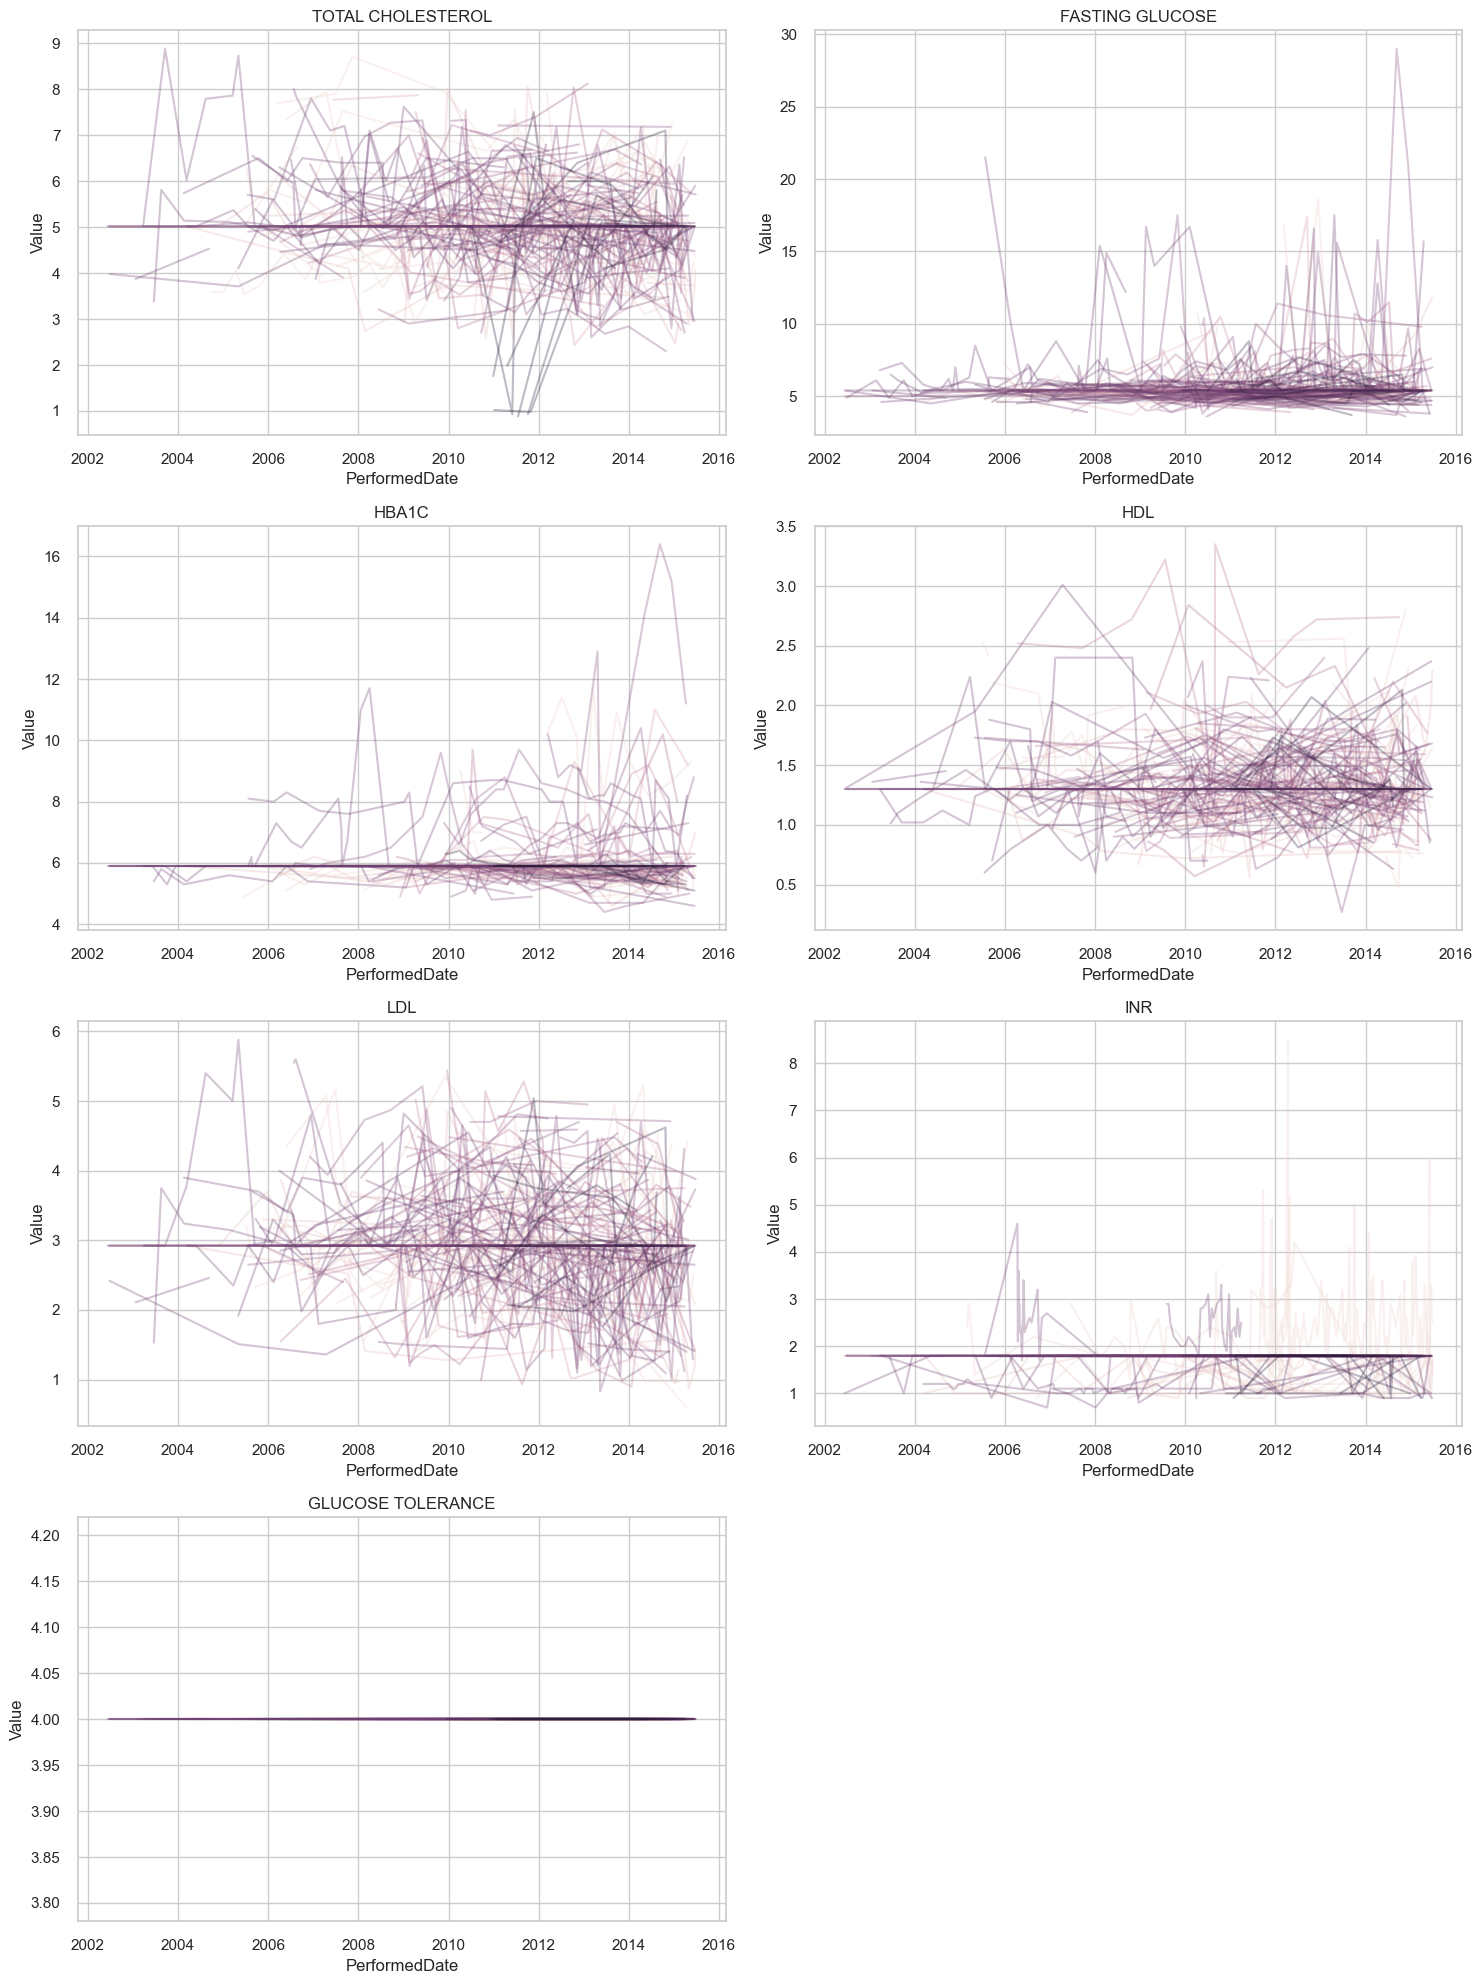

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# transform PerformedDate to datetime
df['PerformedDate'] = pd.to_datetime(df['PerformedDate'])

# This is variables of interest
lab_vars = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 
            'HDL', 'LDL', 'INR', 'GLUCOSE TOLERANCE']

plt.figure(figsize=(15, 20))

for i, lab in enumerate(lab_vars, 1):
    plt.subplot(4, 2, i)
    sns.lineplot(data=df, x='PerformedDate', y=lab, hue='Patient_ID', alpha=0.3, legend=None)
    plt.title(lab)
    plt.xlabel('PerformedDate')
    plt.ylabel('Value')

plt.tight_layout()
plt.show()


## After generating the trajectory plots using actual dates, we found the patterns to be quite messy and difficult to interpret. To address this, we standardized the 'PerformedDate' by converting it to a 'VisitOrder' variable—grouping by patient and ordering their lab test records chronologically.

In [132]:
import pandas as pd

df['PerformedDate'] = pd.to_datetime(df['PerformedDate'])

# Sort by Patient_ID and PerformedDate, then assign visit order per patient
df = df.sort_values(['Patient_ID', 'PerformedDate'])

df['VisitOrder'] = df.groupby('Patient_ID').cumcount() + 1

# View the result
print(df[['Patient_ID', 'PerformedDate', 'VisitOrder']].head(10))


          Patient_ID PerformedDate  VisitOrder
2   1002000000003382    2012-11-27           1
0   1002000000003382    2013-07-08           2
4   1002000000003382    2014-04-29           3
1   1002000000003382    2014-05-28           4
3   1002000000003382    2014-08-26           5
5   1002000000004471    2008-11-05           1
9   1002000000008831    2007-06-18           1
10  1002000000008831    2008-07-14           2
8   1002000000008831    2009-02-09           3
7   1002000000008831    2009-11-30           4


## How many individuals are present at each visit?

Descriptive statistics of total visits per patient:
count    293.000000
mean       5.498294
std       12.221871
min        1.000000
25%        1.000000
50%        3.000000
75%        6.000000
max      189.000000
Name: TotalVisits, dtype: float64

Frequency distribution of total visits:
TotalVisits
1      89
2      57
3      27
4      23
5      14
6      13
7      14
8       4
9       9
10      8
11      9
12      3
13      2
14      1
15      2
16      2
17      1
19      2
20      2
21      1
25      2
26      2
28      3
33      1
35      1
189     1
Name: count, dtype: int64


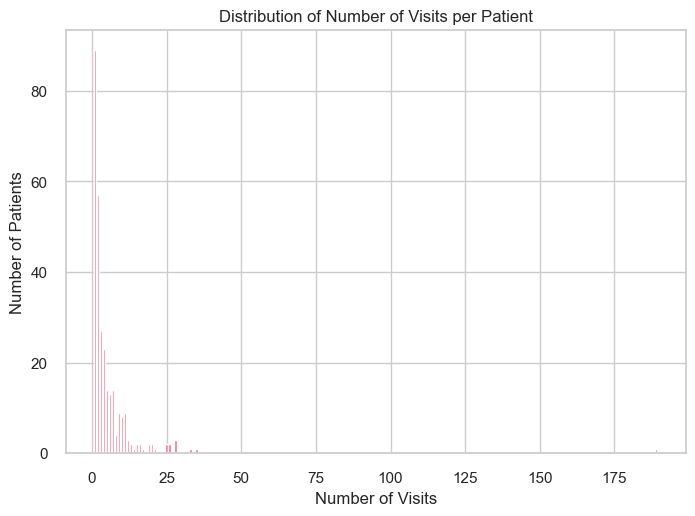

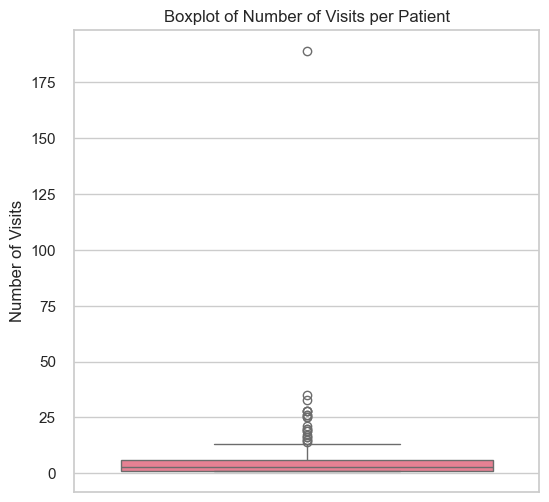

In [133]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate the total number of visits per patient
visit_counts = df.groupby('Patient_ID')['VisitOrder'].max().reset_index(name='TotalVisits')

# Descriptive statistics
print("Descriptive statistics of total visits per patient:")
print(visit_counts['TotalVisits'].describe())

# Frequency distribution
print("\nFrequency distribution of total visits:")
print(visit_counts['TotalVisits'].value_counts().sort_index())

# Histogram of Number of Visits per Patient
plt.hist(visit_counts['TotalVisits'], bins=range(1, visit_counts['TotalVisits'].max()+2), align='left', rwidth=0.8)
plt.xlabel('Number of Visits')
plt.ylabel('Number of Patients')
plt.title('Distribution of Number of Visits per Patient')
plt.show()

# Boxplot of Number of Visits per Patient
plt.figure(figsize=(6, 6))
sns.boxplot(y=visit_counts['TotalVisits'])
plt.title('Boxplot of Number of Visits per Patient')
plt.ylabel('Number of Visits')
plt.show()


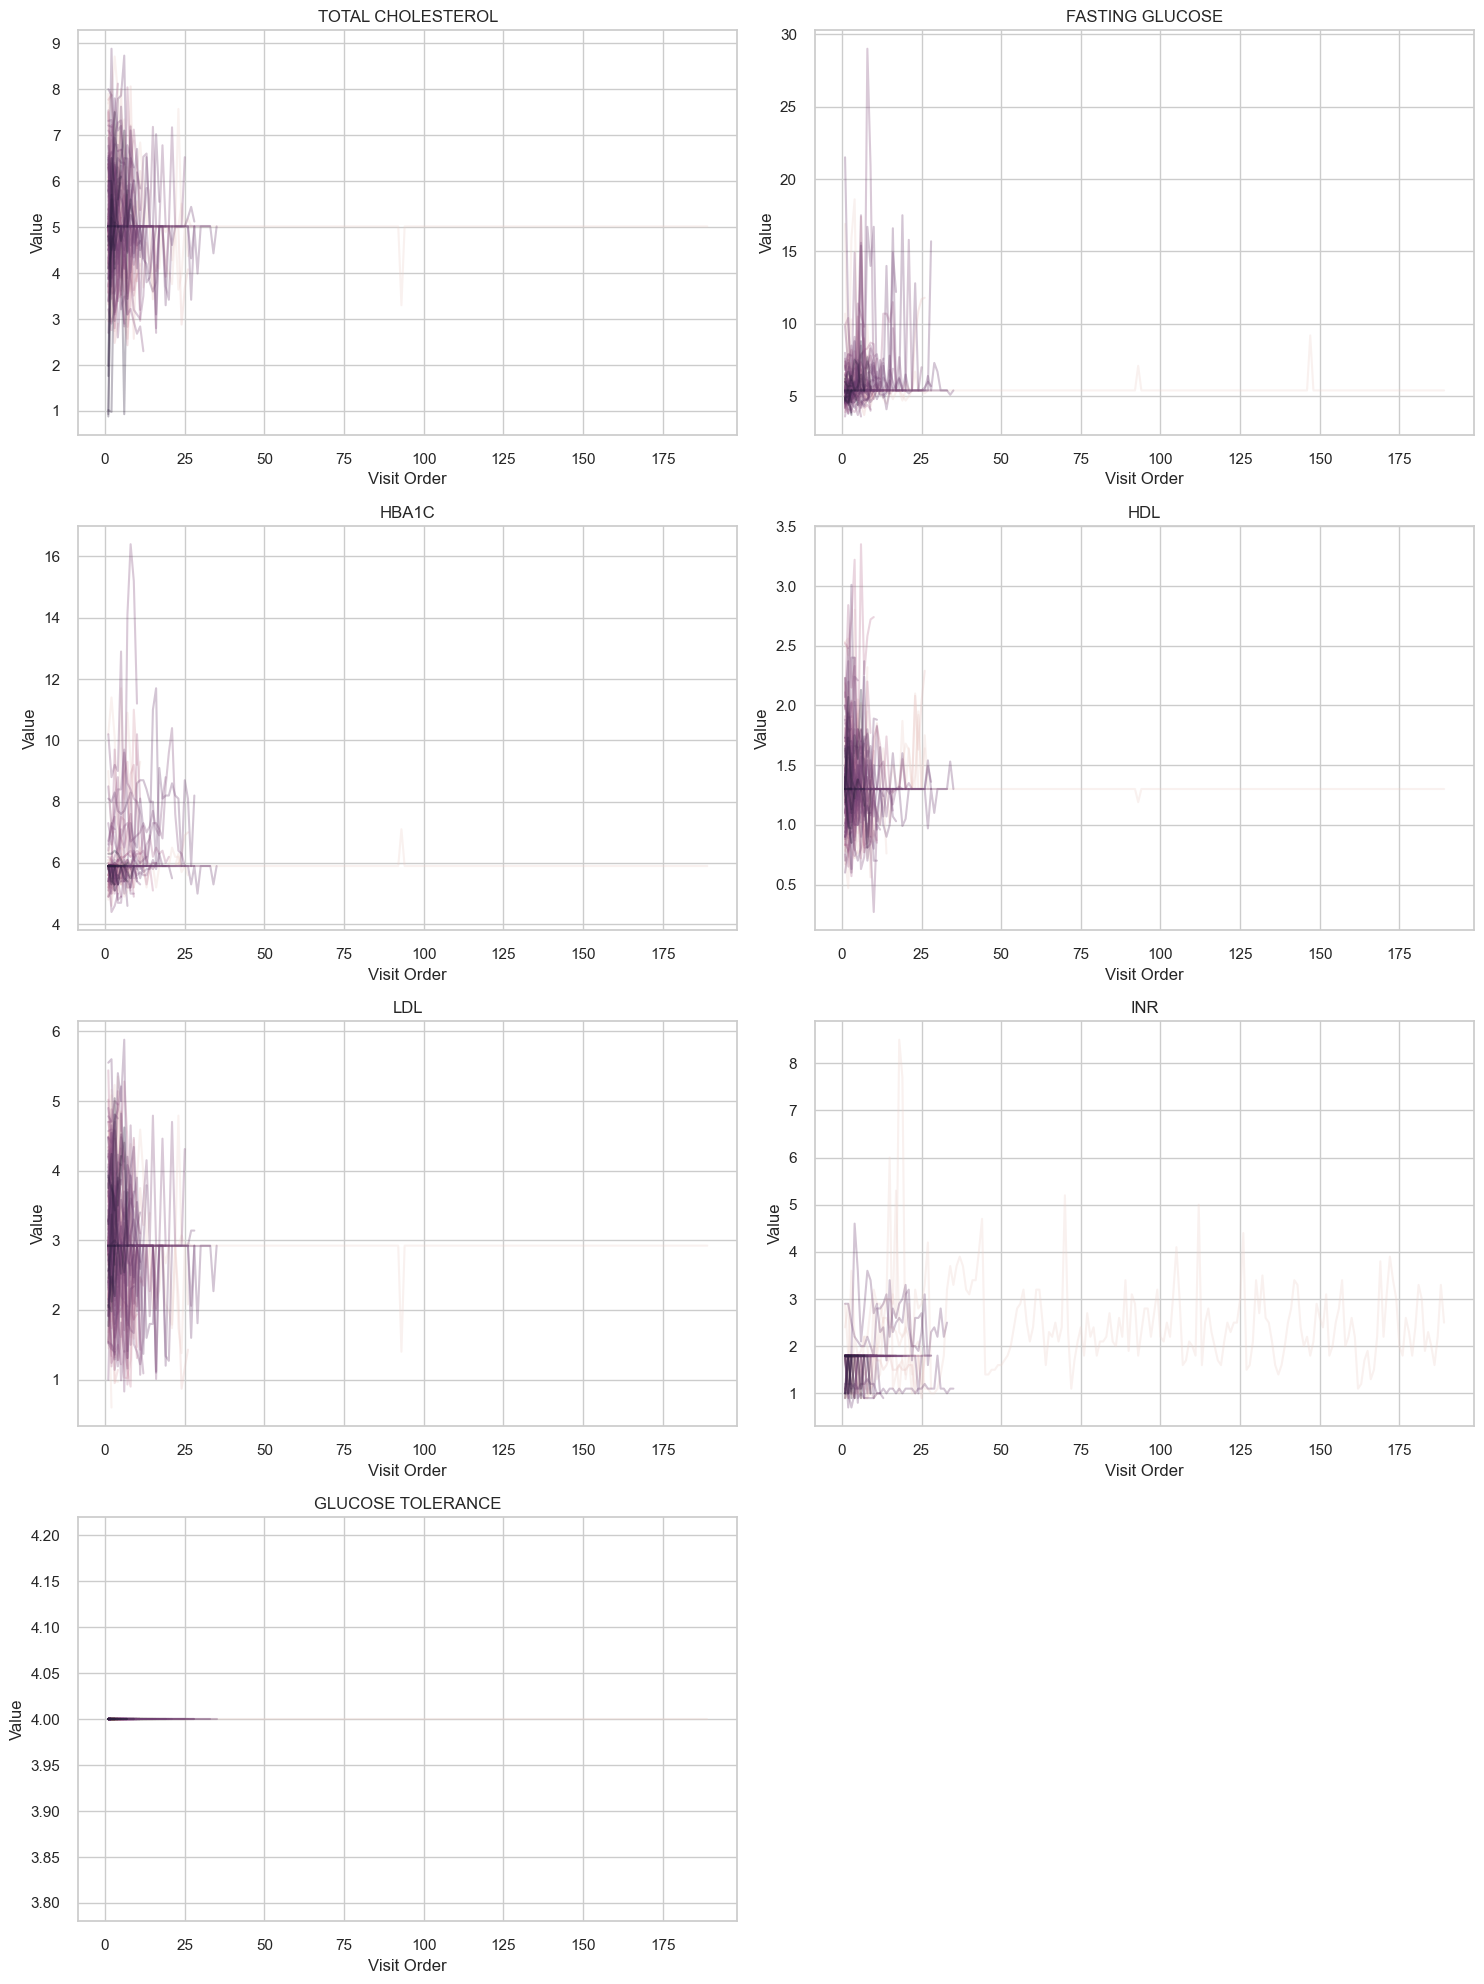

In [134]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure the date format is correct
df['PerformedDate'] = pd.to_datetime(df['PerformedDate'])

# Sort and calculate the visit order for each patient
df = df.sort_values(['Patient_ID', 'PerformedDate'])
df['VisitOrder'] = df.groupby('Patient_ID').cumcount() + 1

lab_vars = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 
            'HDL', 'LDL', 'INR', 'GLUCOSE TOLERANCE']

plt.figure(figsize=(15, 20))

for i, lab in enumerate(lab_vars, 1):
    plt.subplot(4, 2, i)
    sns.lineplot(data=df, x='VisitOrder', y=lab, hue='Patient_ID', alpha=0.3, legend=None)
    plt.title(lab)
    plt.xlabel('Visit Order')
    plt.ylabel('Value')

plt.tight_layout()
plt.show()


## We observe that most individuals have up to 25 visits. Therefore, by focusing on data from the first 25 visits, we can gain more insight into the characteristics of their lab test results.

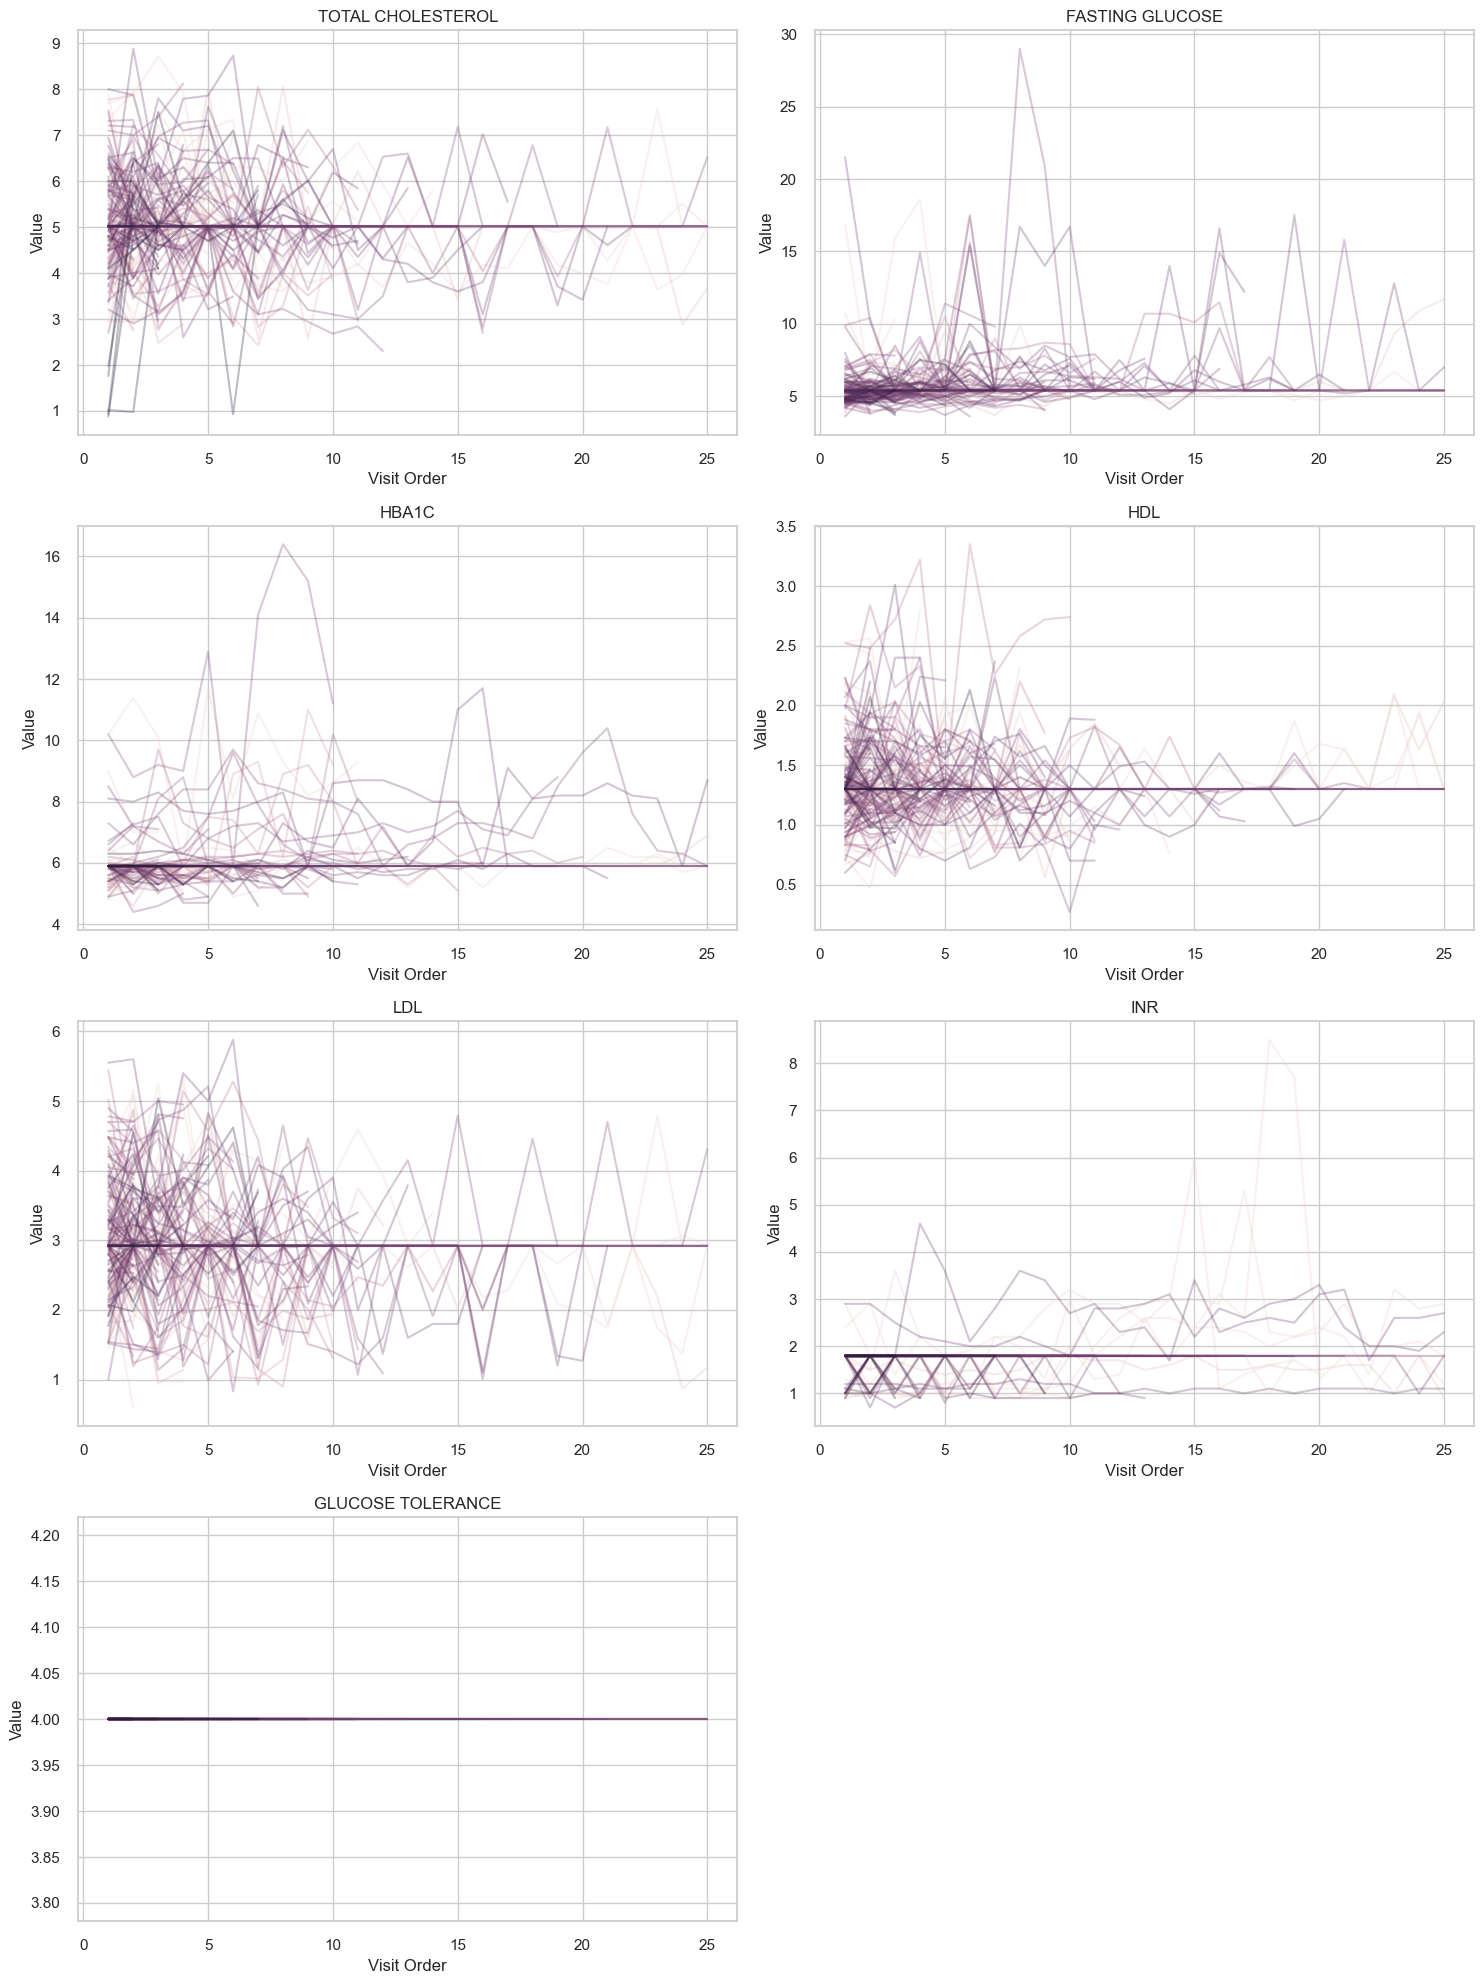

In [135]:
# keep first 25 visits
df_25 = df[df['VisitOrder'] <= 25]

plt.figure(figsize=(15, 20))

for i, lab in enumerate(lab_vars, 1):
    plt.subplot(4, 2, i)
    sns.lineplot(data=df_25, x='VisitOrder', y=lab, hue='Patient_ID', alpha=0.3, legend=None)
    plt.title(lab)
    plt.xlabel('Visit Order')
    plt.ylabel('Value')

plt.tight_layout()
plt.show()


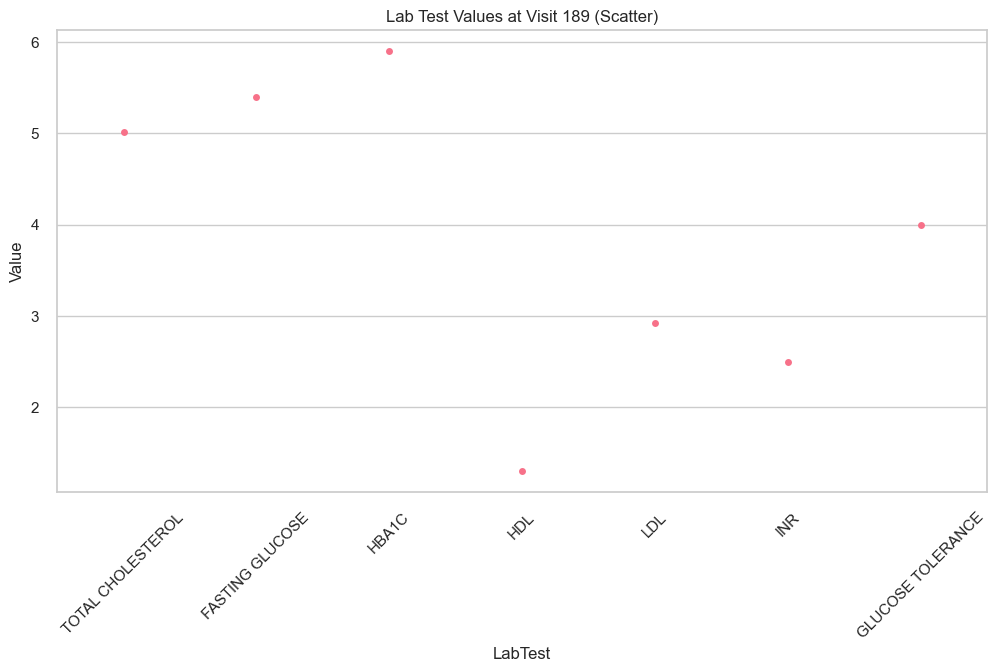

In [157]:
df_189 = df[df['VisitOrder'] == 189]

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
lab_vars = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 
            'HDL', 'LDL', 'INR', 'GLUCOSE TOLERANCE']

df_189_long = df_189.melt(id_vars=['Patient_ID'], value_vars=lab_vars, 
                         var_name='LabTest', value_name='Value')

sns.swarmplot(x='LabTest', y='Value', data=df_189_long)
plt.title('Lab Test Values at Visit 189 (Scatter)')
plt.xticks(rotation=45)
plt.show()


## Only one individual has 189 visits, and we examine the trend of their lab data over time.

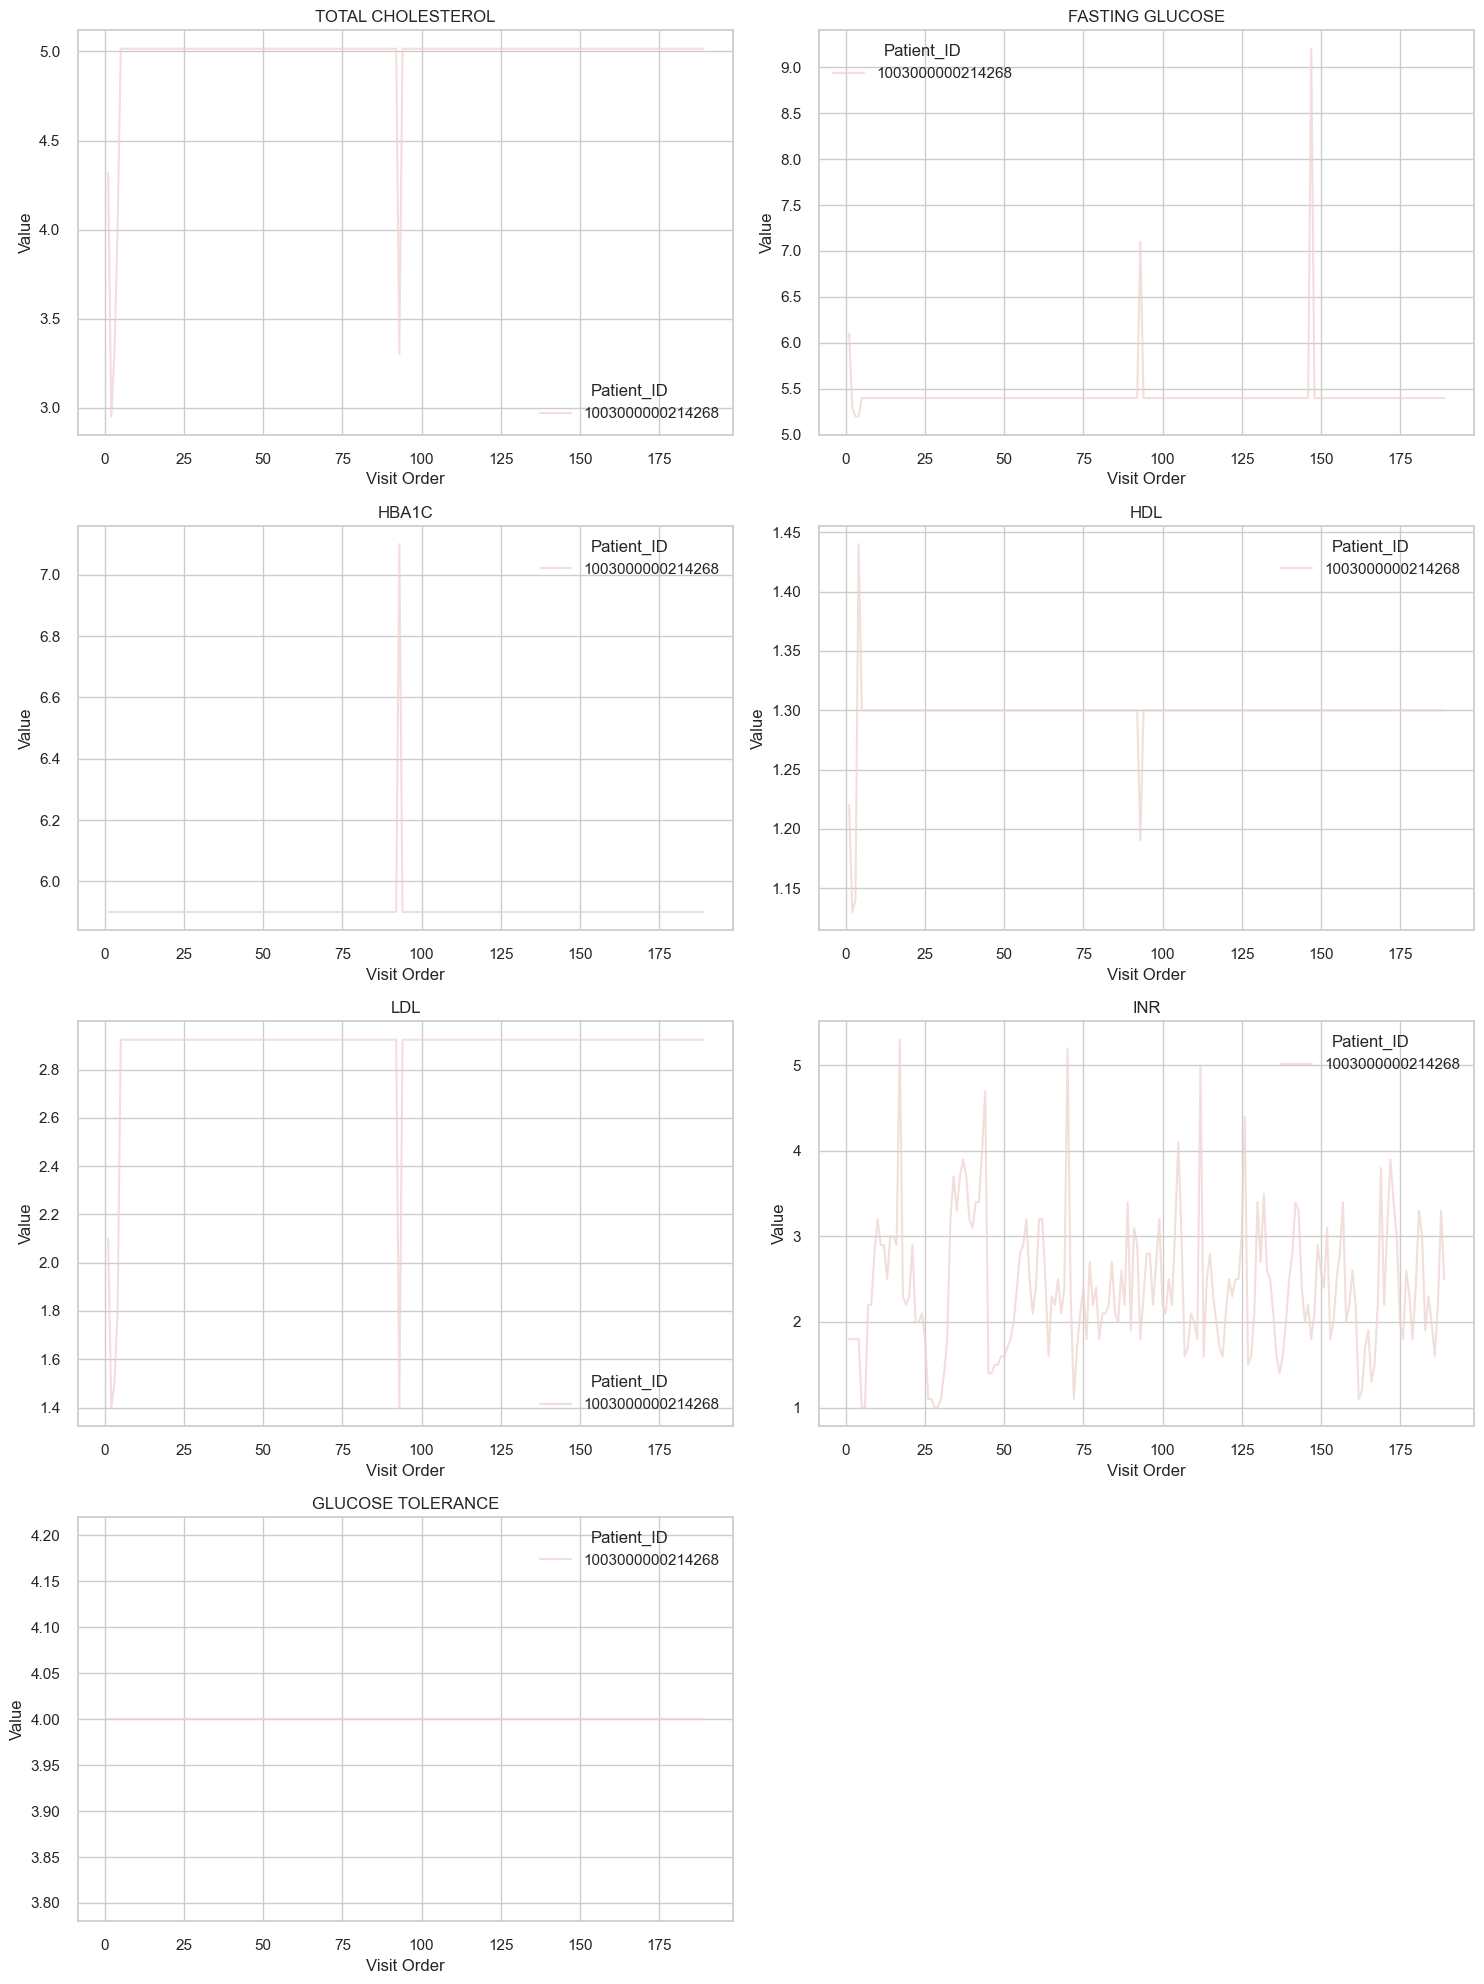

In [137]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Find the list of Patient_IDs who have VisitOrder == 189
patients_189 = df.loc[df['VisitOrder'] == 189, 'Patient_ID'].unique()

df_patients = df[df['Patient_ID'].isin(patients_189)]

lab_vars = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR', 'GLUCOSE TOLERANCE']

plt.figure(figsize=(15, 20))

# x-axis is VisitOrder, y-axis is the lab value
for i, lab in enumerate(lab_vars, 1):
    plt.subplot(4, 2, i)
    sns.lineplot(data=df_patients, x='VisitOrder', y=lab, hue='Patient_ID', alpha=0.7)
    plt.title(lab)
    plt.xlabel('Visit Order')
    plt.ylabel('Value')

plt.tight_layout()
plt.show()



In [138]:
lab_vars = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR', 'GLUCOSE TOLERANCE']

corr_matrix = df[lab_vars].corr()

print(corr_matrix)


                   TOTAL CHOLESTEROL  FASTING GLUCOSE     HBA1C       HDL  \
TOTAL CHOLESTEROL           1.000000        -0.075347 -0.047125  0.159656   
FASTING GLUCOSE            -0.075347         1.000000  0.473909 -0.091966   
HBA1C                      -0.047125         0.473909  1.000000 -0.080046   
HDL                         0.159656        -0.091966 -0.080046  1.000000   
LDL                         0.782300        -0.130486 -0.090317  0.014333   
INR                         0.014615        -0.021287 -0.005984 -0.003081   
GLUCOSE TOLERANCE                NaN              NaN       NaN       NaN   

                        LDL       INR  GLUCOSE TOLERANCE  
TOTAL CHOLESTEROL  0.782300  0.014615                NaN  
FASTING GLUCOSE   -0.130486 -0.021287                NaN  
HBA1C             -0.090317 -0.005984                NaN  
HDL                0.014333 -0.003081                NaN  
LDL                1.000000  0.022787                NaN  
INR                0.022787  

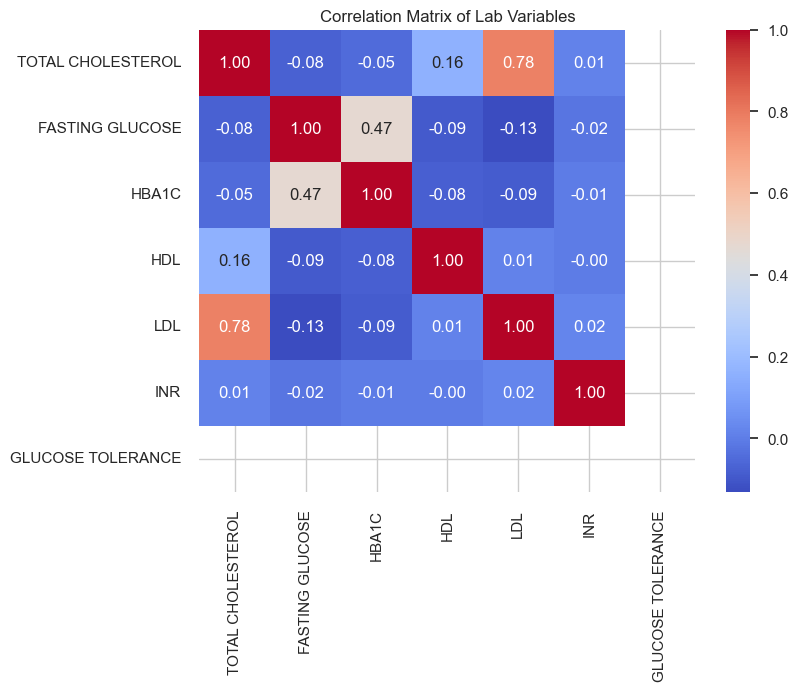

In [139]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Lab Variables')
plt.show()

## To be specific, bipolar disorder has various subtypes, so we examine the lab test results corresponding to each subtype. There are seven subtypes of bipolar disorder, which are described below.

In [140]:
df['DiagnosisCode_calc'] = df['DiagnosisCode_calc'].astype(str).str.strip()

codes = ['296.0', '296.1', '296.4', '296.5', '296.6', '296.7', '296.8']
df['State_factor'] = pd.Categorical(df['DiagnosisCode_calc'], categories=codes, ordered=True)
df['State_factor_num'] = df['State_factor'].cat.codes
print(df[['DiagnosisCode_calc', 'State_factor', 'State_factor_num']].head(10))


   DiagnosisCode_calc State_factor  State_factor_num
2               296.4        296.4                 2
0               296.4        296.4                 2
4               296.4        296.4                 2
1               296.4        296.4                 2
3               296.4        296.4                 2
5               296.7        296.7                 5
9               296.4        296.4                 2
10              296.4        296.4                 2
8               296.4        296.4                 2
7               296.4        296.4                 2


/var/folders/rz/1kbc3h7x1b94g5f531rphh5m0000gn/T/ipykernel_1526/2827126568.py:9: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Mean lab test values by Bipolar subtype:
               TOTAL CHOLESTEROL  FASTING GLUCOSE     HBA1C       HDL  \
State_factor                                                           
296.0                  6.056667         5.266667  5.900000  1.185000   
296.1                  5.052148         5.372093  5.798837  1.577209   
296.4                  4.997143         5.637937  6.001748  1.311678   
296.5                  4.220000         5.400000  5.900000  1.687500   
296.6                  4.340000         5.400000  6.100000  1.190000   
296.7                  5.021822         5.745770  6.084506  1.312200   
296.8                  3.960000         4.200000  5.900000  1.640000   

                   LDL       INR  GLUCOSE TOLERANCE  
State_factor                                         
296.0         4.191667  1.800000                4.0  
296.1         3.020993  1.800000                4.0  
296.4         2.922456  1.811538                4.0  
296.5         2.830226  1.800000       

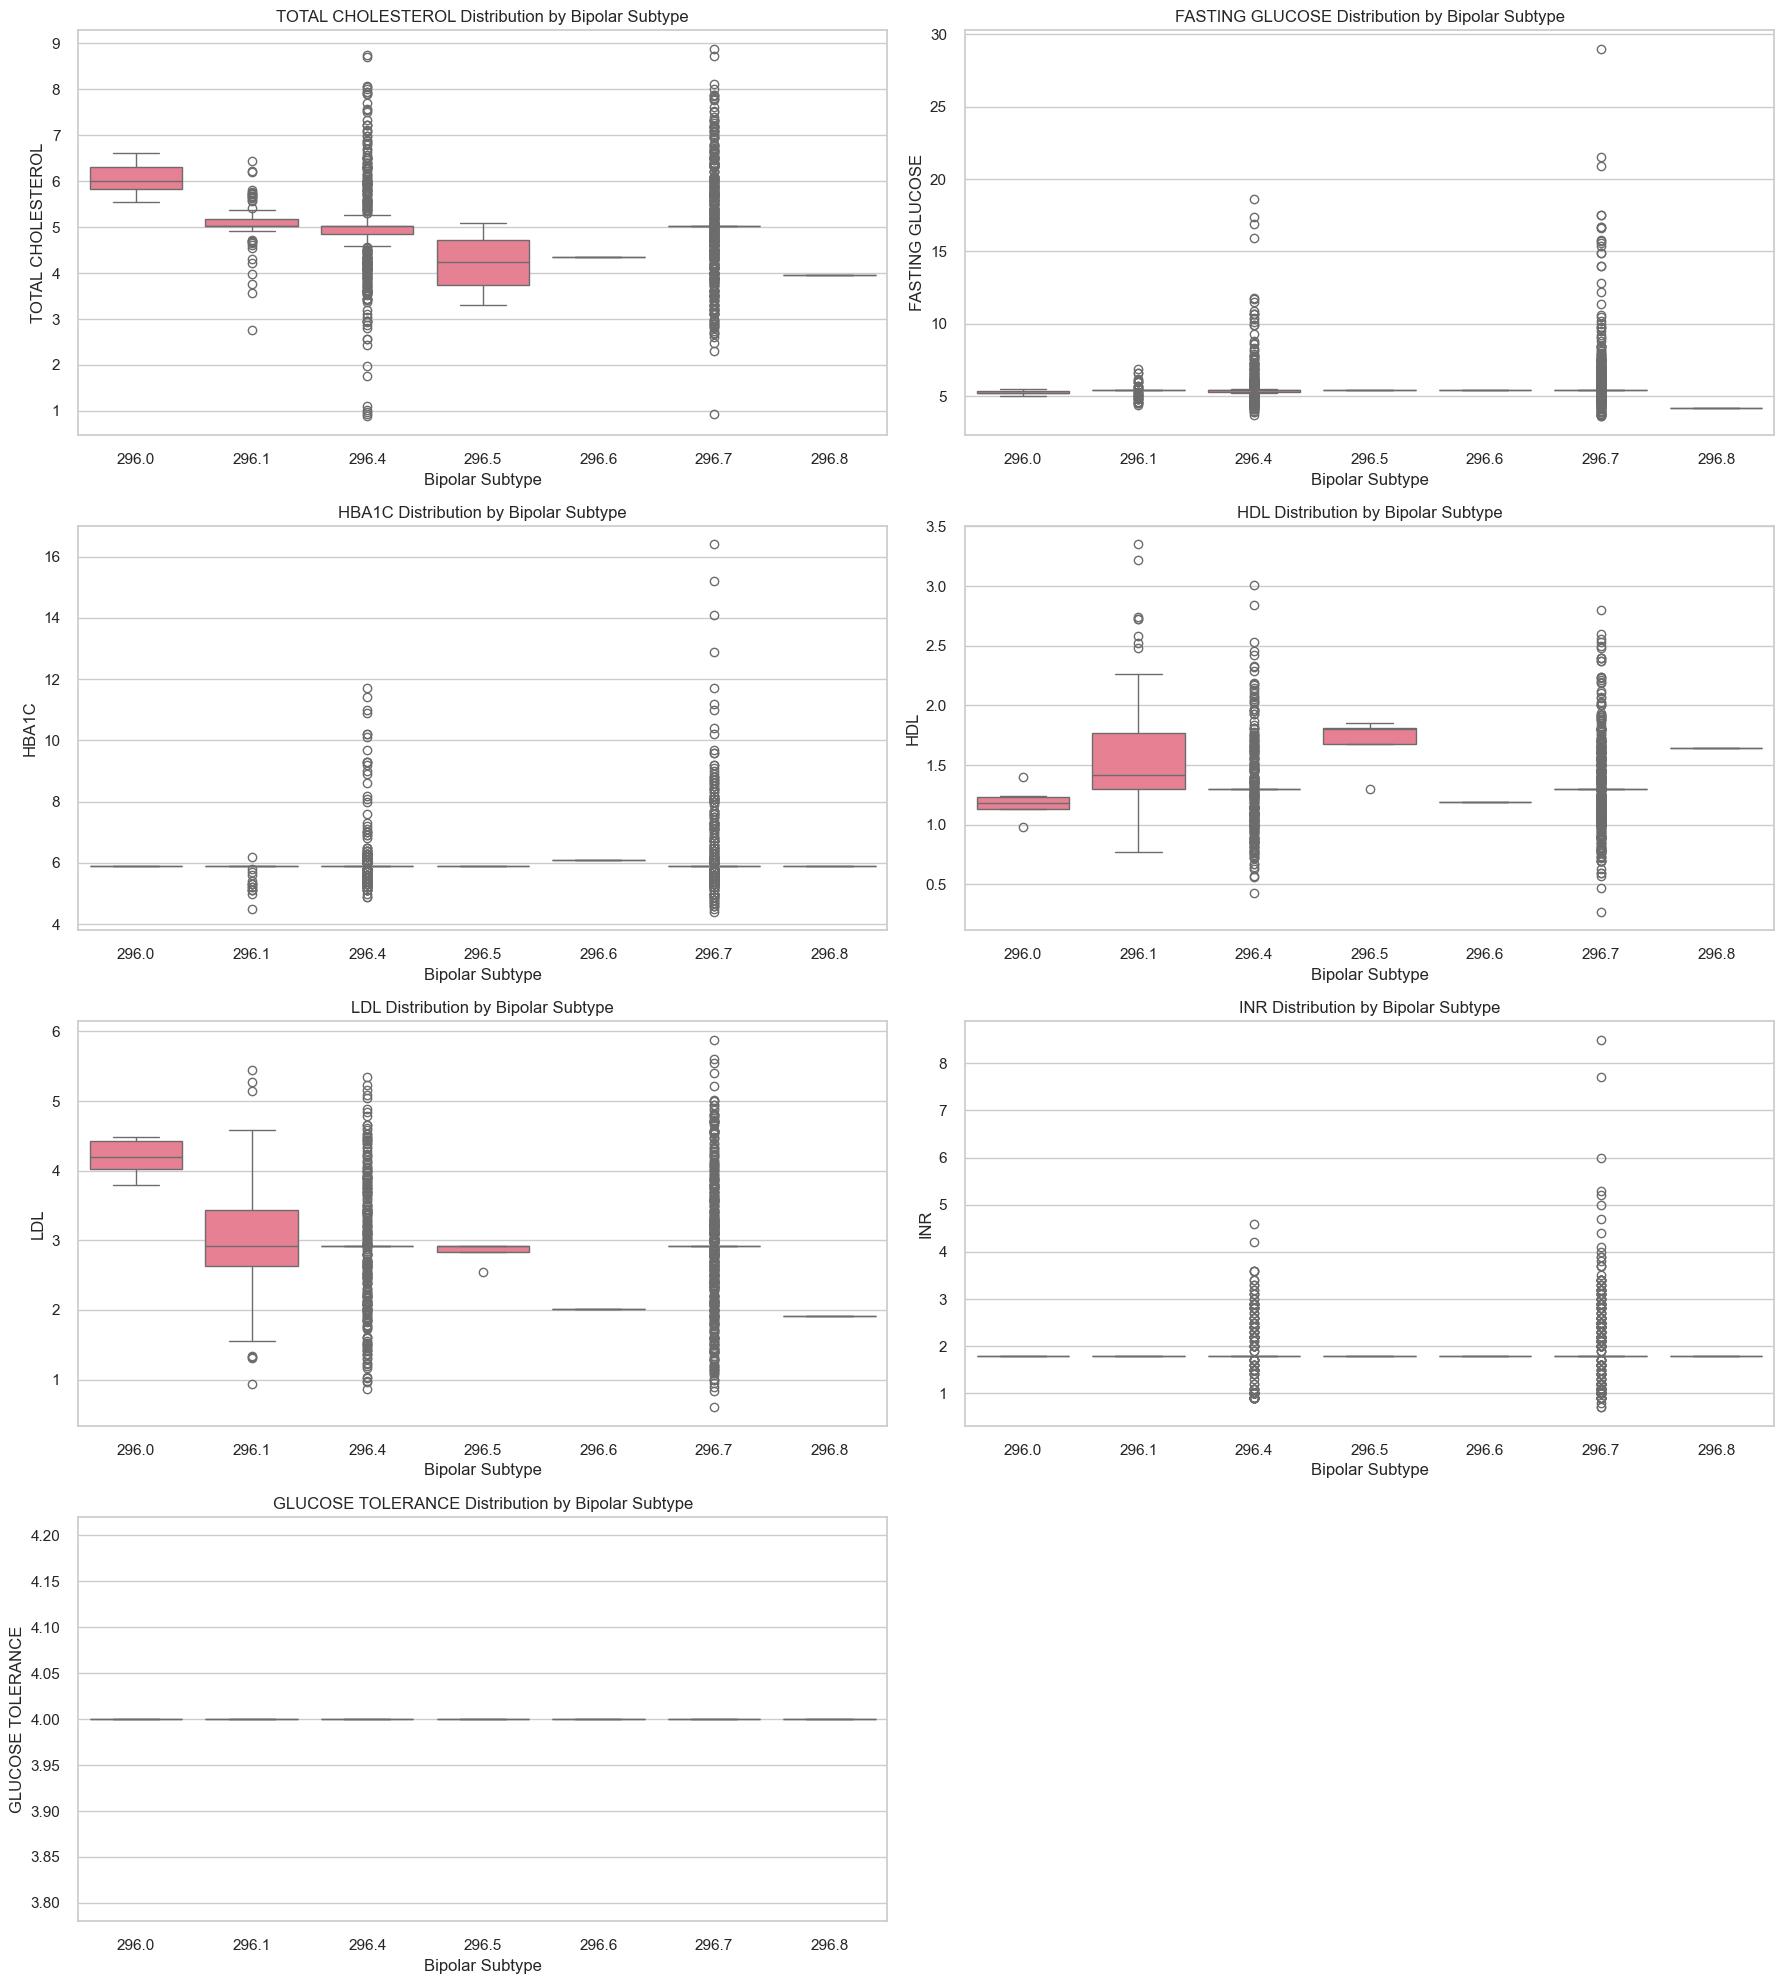

In [141]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

lab_vars = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR', 'GLUCOSE TOLERANCE']

# calculate the mean of subtypes
mean_df = df_clean.groupby('State_factor')[lab_vars].mean()
print("Mean lab test values by Bipolar subtype:\n", mean_df)

# boxplot of distribution of subtypes
plt.figure(figsize=(18, 20))
for i, lab in enumerate(lab_vars, 1):
    plt.subplot(4, 2, i)
    sns.boxplot(data=df_clean, x='State_factor', y=lab)
    plt.title(f'{lab} Distribution by Bipolar Subtype')
    plt.xlabel('Bipolar Subtype')
    plt.ylabel(lab)

plt.tight_layout()
plt.show()

/var/folders/rz/1kbc3h7x1b94g5f531rphh5m0000gn/T/ipykernel_1526/3377964870.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/rz/1kbc3h7x1b94g5f531rphh5m0000gn/T/ipykernel_1526/3377964870.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/rz/1kbc3h7x1b94g5f531rphh5m0000gn/T/ipykernel_1526/3377964870.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/rz/1kbc3h7x1b94g5f531rphh5m

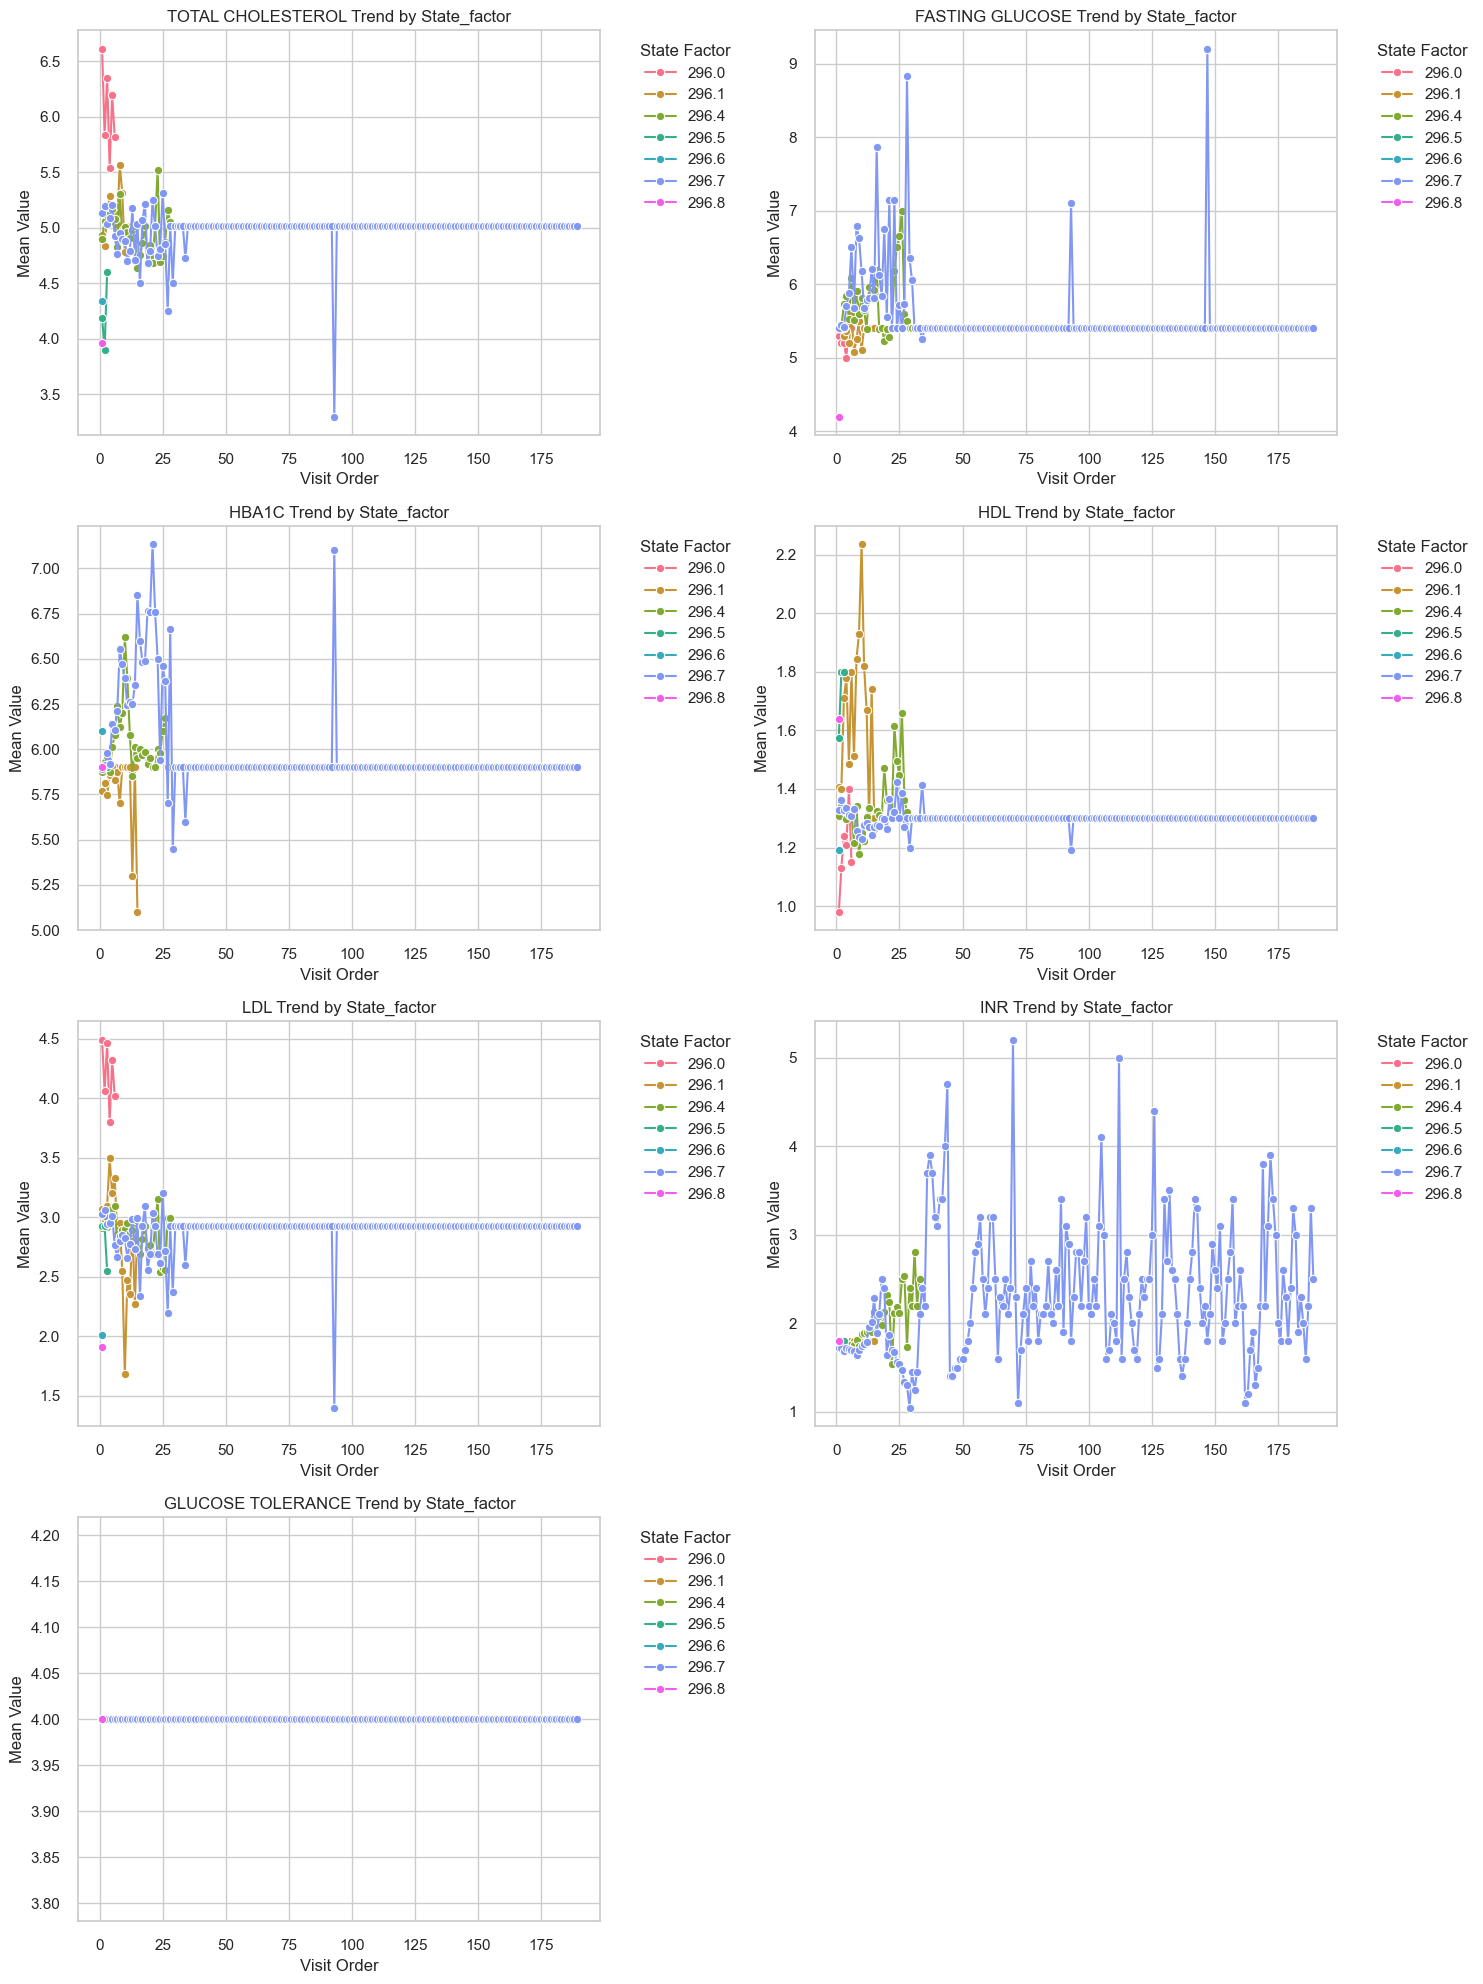

In [142]:
import seaborn as sns
import matplotlib.pyplot as plt

lab_vars = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR', 'GLUCOSE TOLERANCE']

plt.figure(figsize=(15, 20))

for i, lab in enumerate(lab_vars, 1):
    plt.subplot(4, 2, i)
    summary = df.groupby(['State_factor', 'VisitOrder'])[lab].mean().reset_index()
    summary = summary.dropna(subset=['State_factor', lab])
    if summary.empty:
        print(f"No data for {lab}")
        continue
    sns.lineplot(data=summary, x='VisitOrder', y=lab, hue='State_factor', marker='o')
    plt.title(f'{lab} Trend by State_factor')
    plt.xlabel('Visit Order')
    plt.ylabel('Mean Value')
    plt.legend(title='State Factor', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Based on a literature review, we found that bipolar disorder can be categorized into three states: manic, depressed, and calm. Therefore, we recategorized the original seven statuses into these three groups.

In [143]:
# Define a mapping from ICD codes to broad state categories
broad_state_map = {
    '296.0': 'Manic',         # BipolarI_SingleManic
    '296.1': 'Manic',         # BipolarI_RecurrentManic
    '296.4': 'Manic',         # BipolarI_CurrentManic
    '296.5': 'Depressed',     # BipolarI_CurrentDepressed
    '296.6': 'Manic',         # BipolarI_CurrentMixed (assigned to Manic, can adjust if needed)
    '296.7': 'Unspecified',   # BipolarI_Unspecified
    '296.8': 'Unspecified'    # Bipolar_Unspecified
}

df['Broad_State'] = df['DiagnosisCode_calc'].map(broad_state_map)
broad_order = ['Manic', 'Depressed', 'Unspecified']
df['Broad_State_factor'] = pd.Categorical(df['Broad_State'], categories=broad_order, ordered=True)
df['Broad_State_num'] = df['Broad_State_factor'].cat.codes

print(df[['Broad_State_factor', 'Broad_State_num']].head(10))

   Broad_State_factor  Broad_State_num
2               Manic                0
0               Manic                0
4               Manic                0
1               Manic                0
3               Manic                0
5         Unspecified                2
9               Manic                0
10              Manic                0
8               Manic                0
7               Manic                0


/var/folders/rz/1kbc3h7x1b94g5f531rphh5m0000gn/T/ipykernel_1526/1979261261.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Mean lab test values by Broad State:
                     TOTAL CHOLESTEROL  FASTING GLUCOSE     HBA1C       HDL  \
Broad_State_factor                                                           
Manic                        5.012828          5.59985  5.974737  1.344692   
Depressed                    4.220000          5.40000  5.900000  1.687500   
Unspecified                  5.020694          5.74413  6.084310  1.312548   

                         LDL       INR  GLUCOSE TOLERANCE  
Broad_State_factor                                         
Manic               2.945279  1.809925                4.0  
Depressed           2.830226  1.800000                4.0  
Unspecified         2.908752  1.862208                4.0  


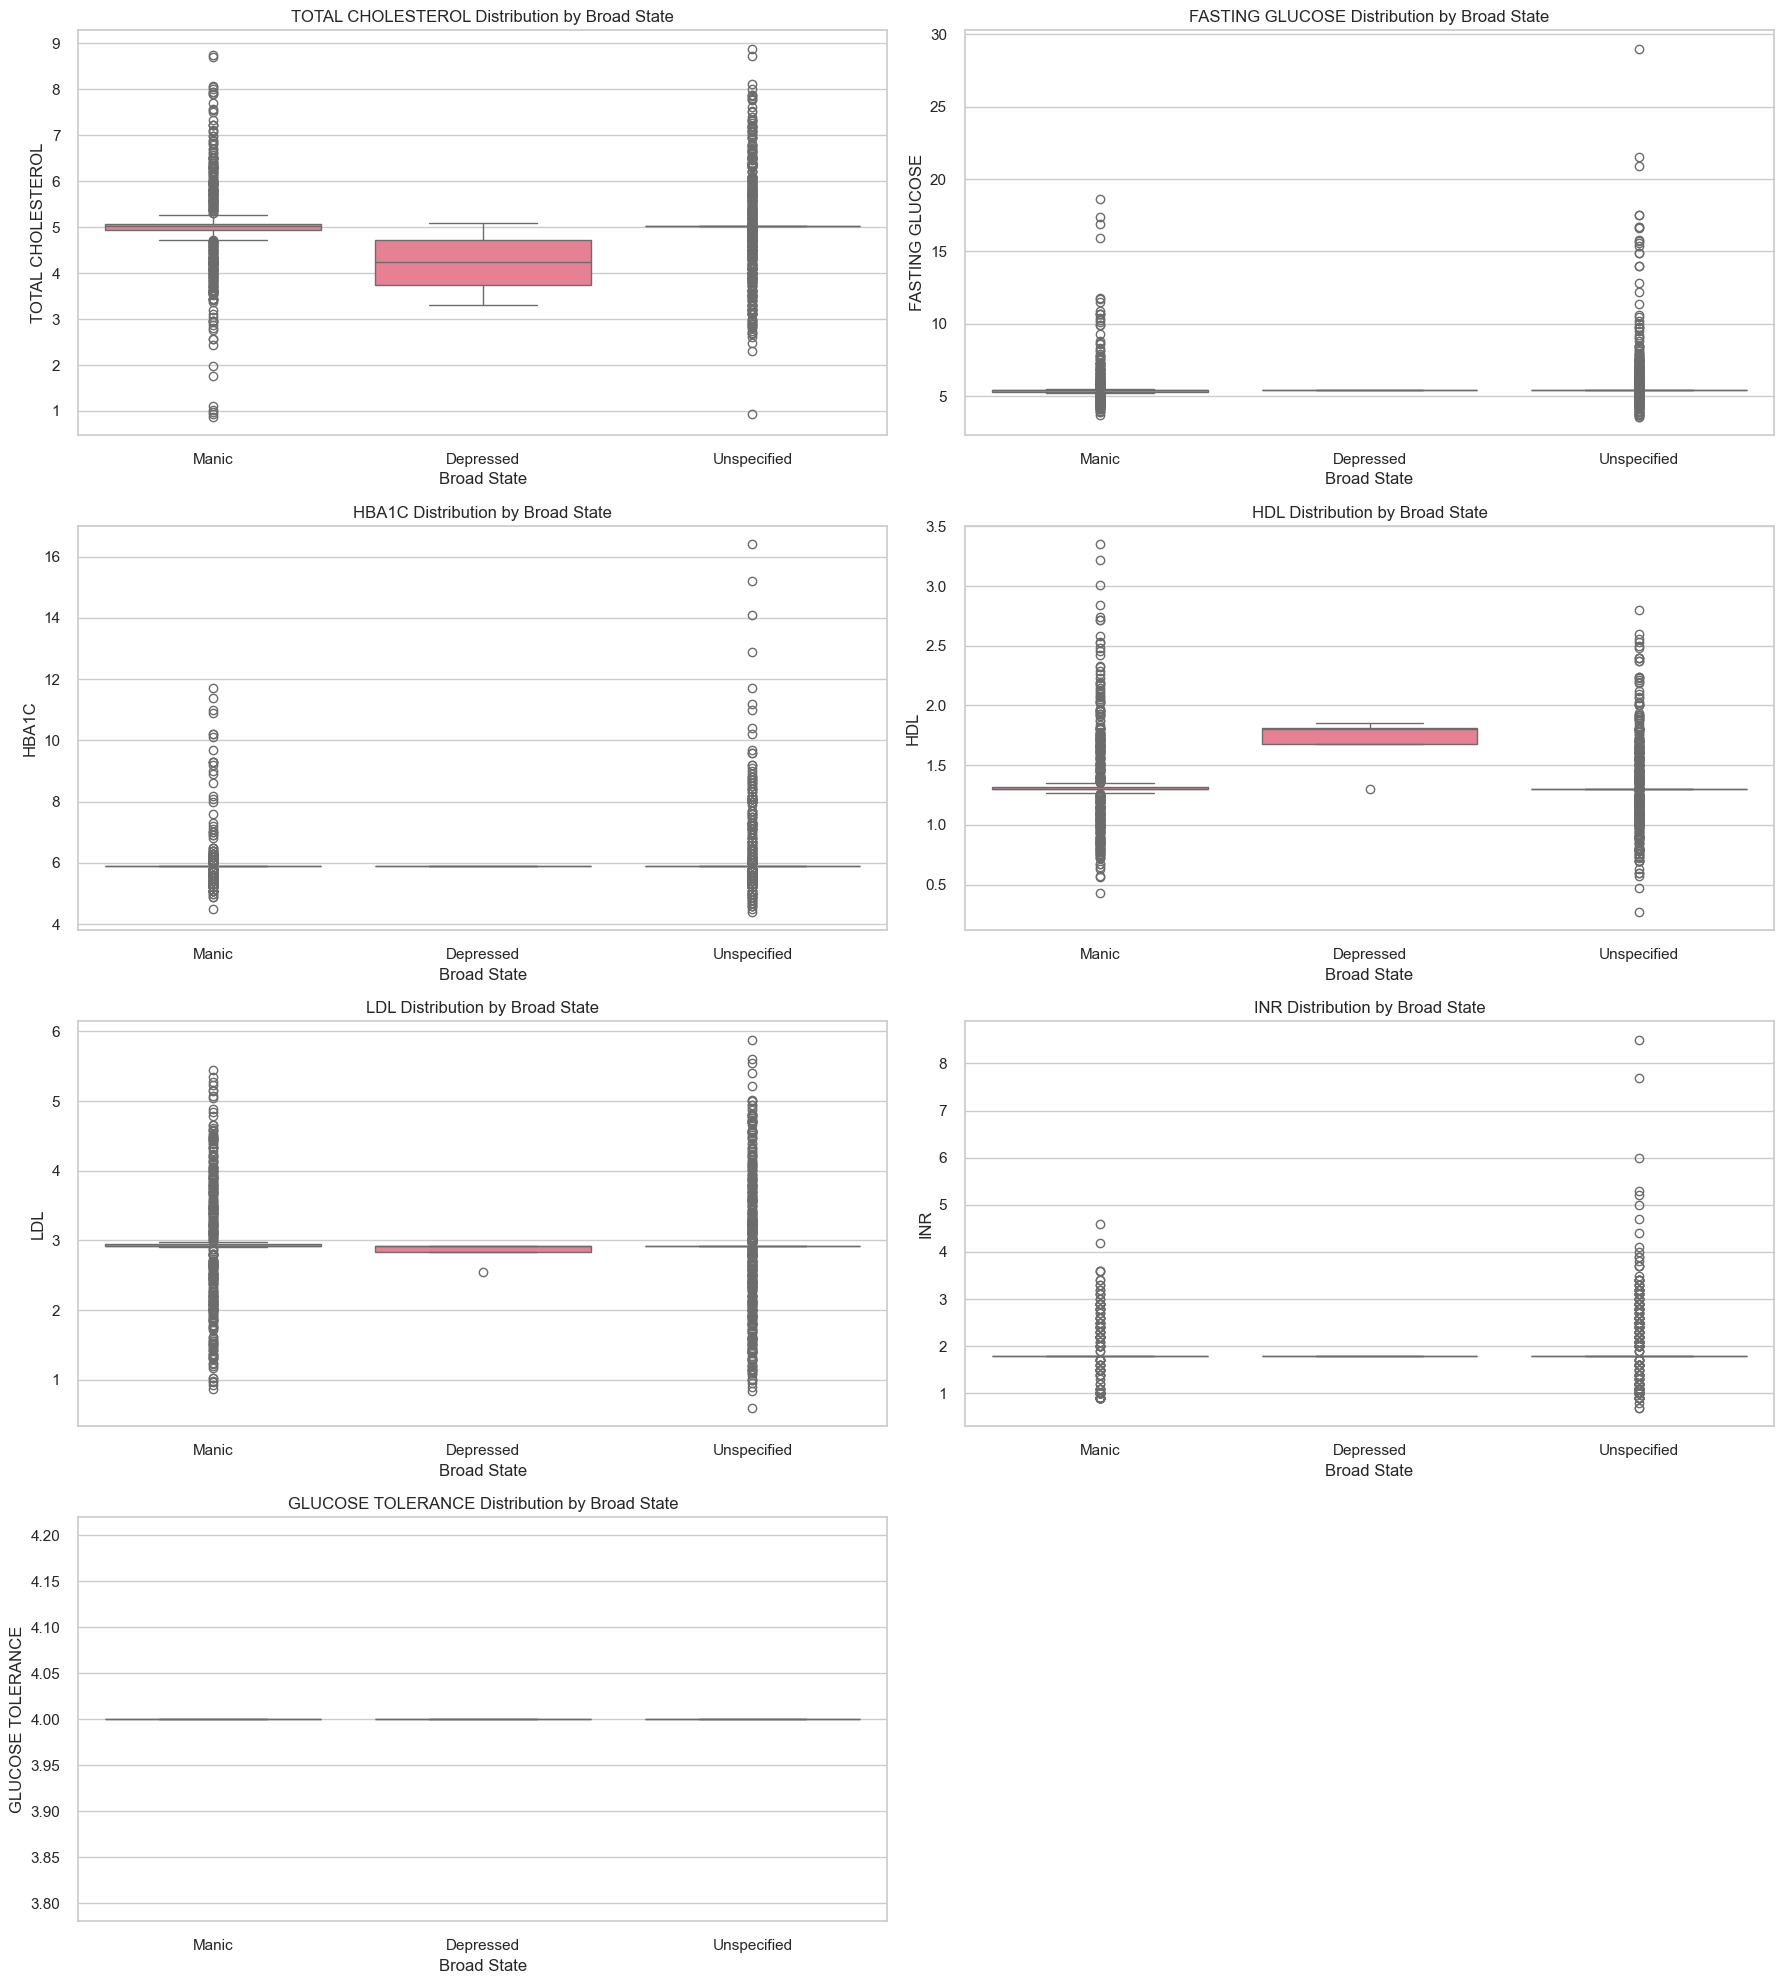

In [144]:
# calculate mean of each states
broad_means = df_clean.groupby('Broad_State_factor')[lab_vars].mean()
print("Mean lab test values by Broad State:\n", broad_means)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 20))
for i, lab in enumerate(lab_vars, 1):
    plt.subplot(4, 2, i)
    sns.boxplot(data=df_clean, x='Broad_State_factor', y=lab)
    plt.title(f'{lab} Distribution by Broad State')
    plt.xlabel('Broad State')
    plt.ylabel(lab)

plt.tight_layout()
plt.show()


/var/folders/rz/1kbc3h7x1b94g5f531rphh5m0000gn/T/ipykernel_1526/2704517200.py:12: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/rz/1kbc3h7x1b94g5f531rphh5m0000gn/T/ipykernel_1526/2704517200.py:12: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/rz/1kbc3h7x1b94g5f531rphh5m0000gn/T/ipykernel_1526/2704517200.py:12: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/rz/1kbc3h7x1b94g5f531rphh5m

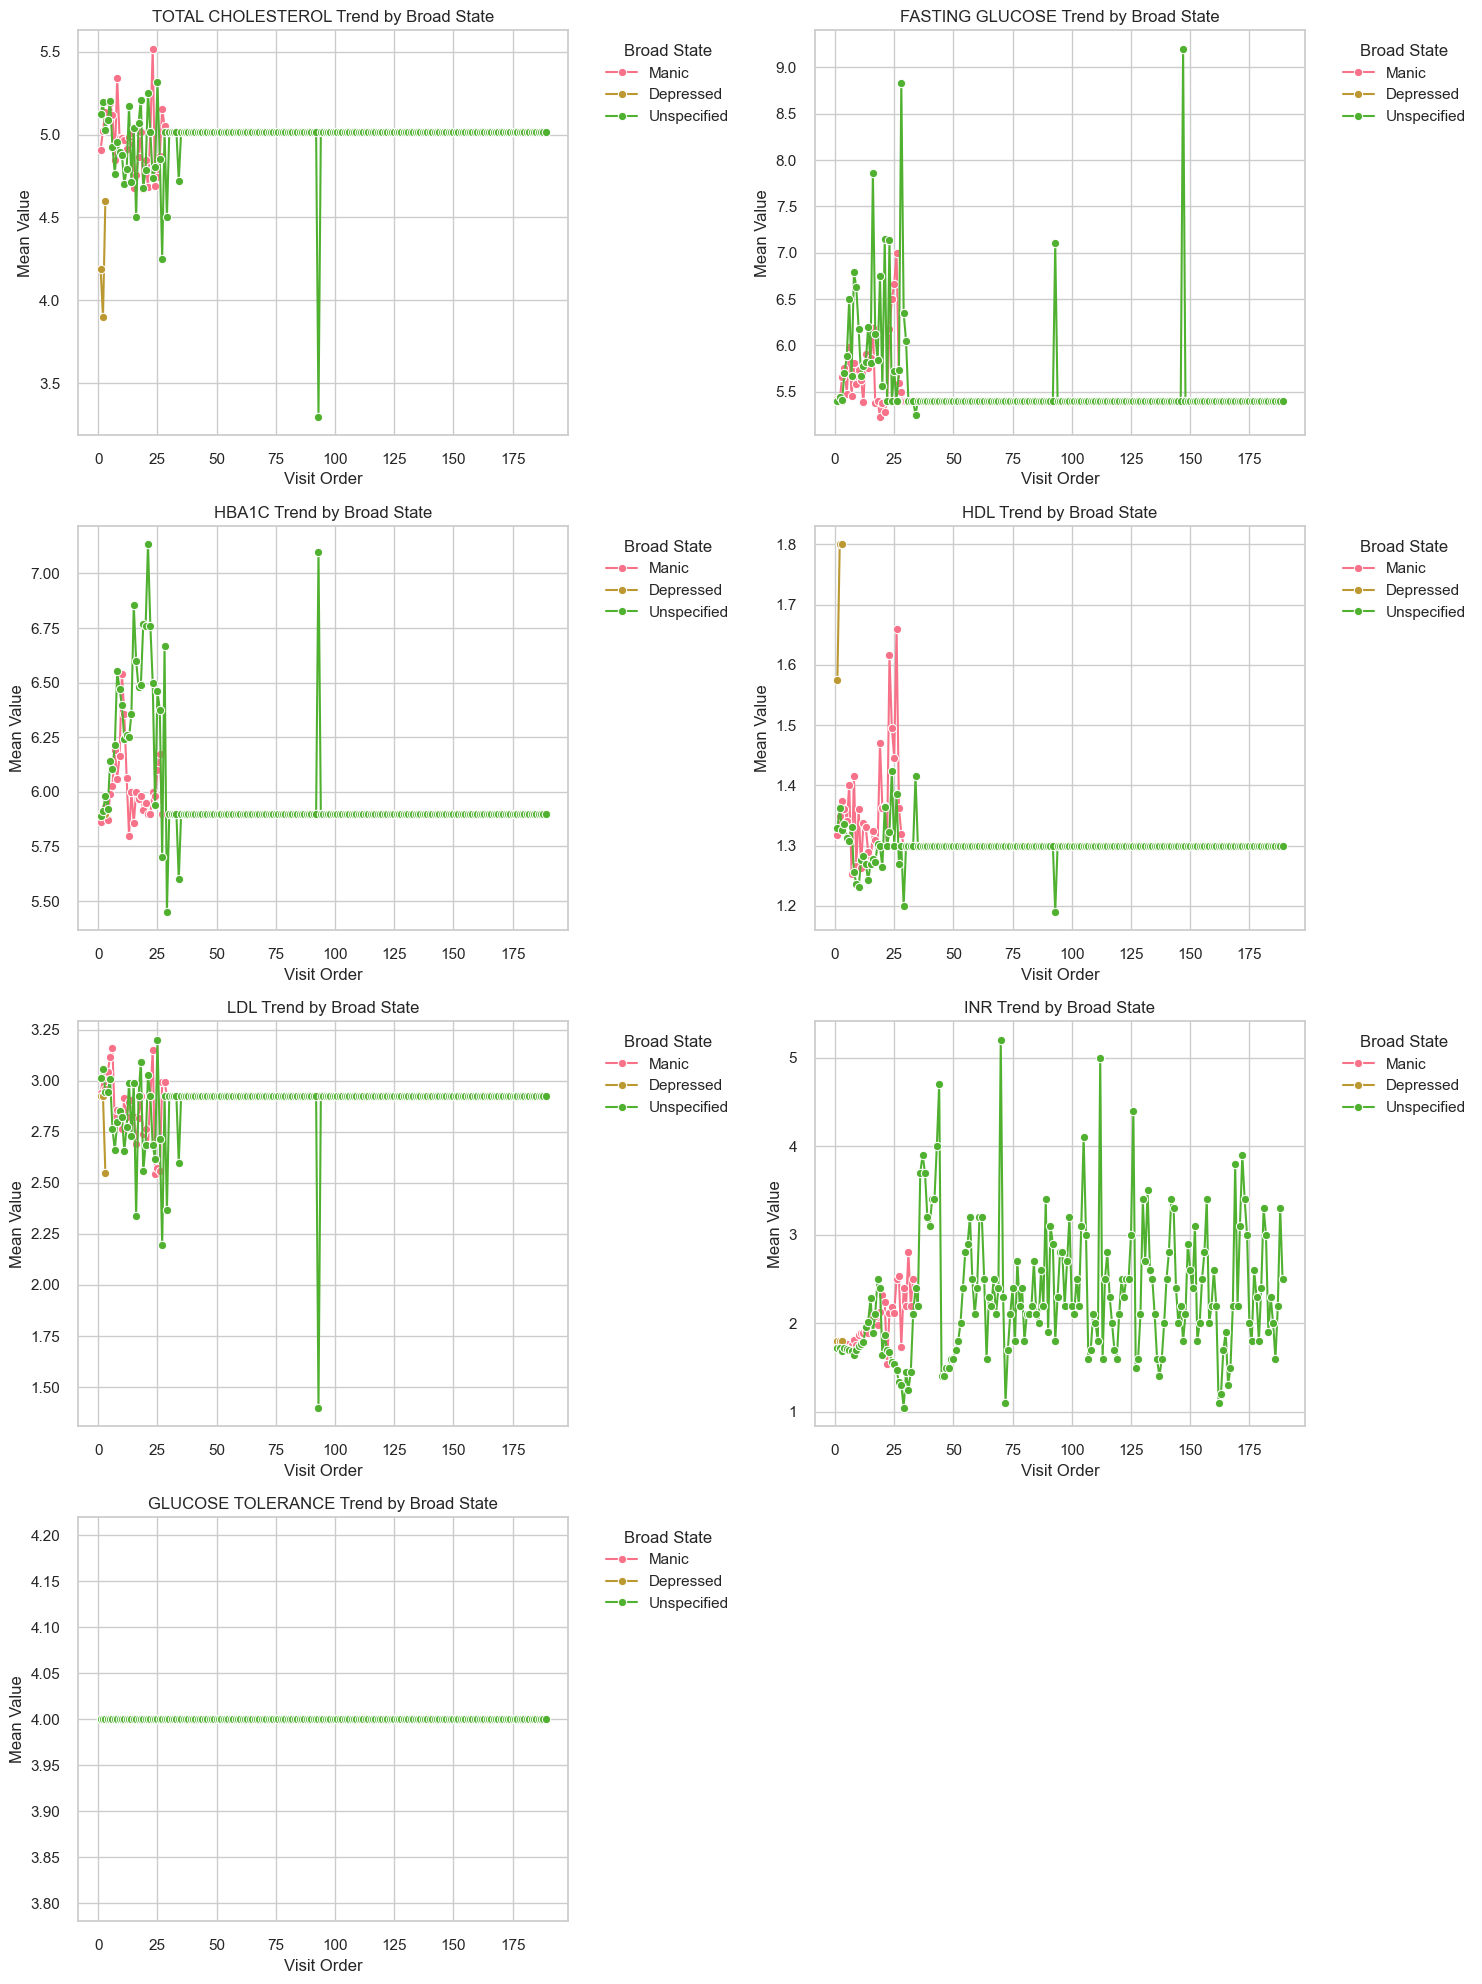

In [145]:
import seaborn as sns
import matplotlib.pyplot as plt

lab_vars = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR', 'GLUCOSE TOLERANCE']

plt.figure(figsize=(15, 20))

for i, lab in enumerate(lab_vars, 1):
    plt.subplot(4, 2, i)
    
    summary = df.groupby(['Broad_State_factor', 'VisitOrder'])[lab].mean().reset_index()
    summary = summary.dropna(subset=['Broad_State_factor', lab])
    if summary.empty:
        print(f"No data for {lab}")
        continue
    
    sns.lineplot(data=summary, x='VisitOrder', y=lab, hue='Broad_State_factor', marker='o')
    
    plt.title(f'{lab} Trend by Broad State')
    plt.xlabel('Visit Order')
    plt.ylabel('Mean Value')
    plt.legend(title='Broad State', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


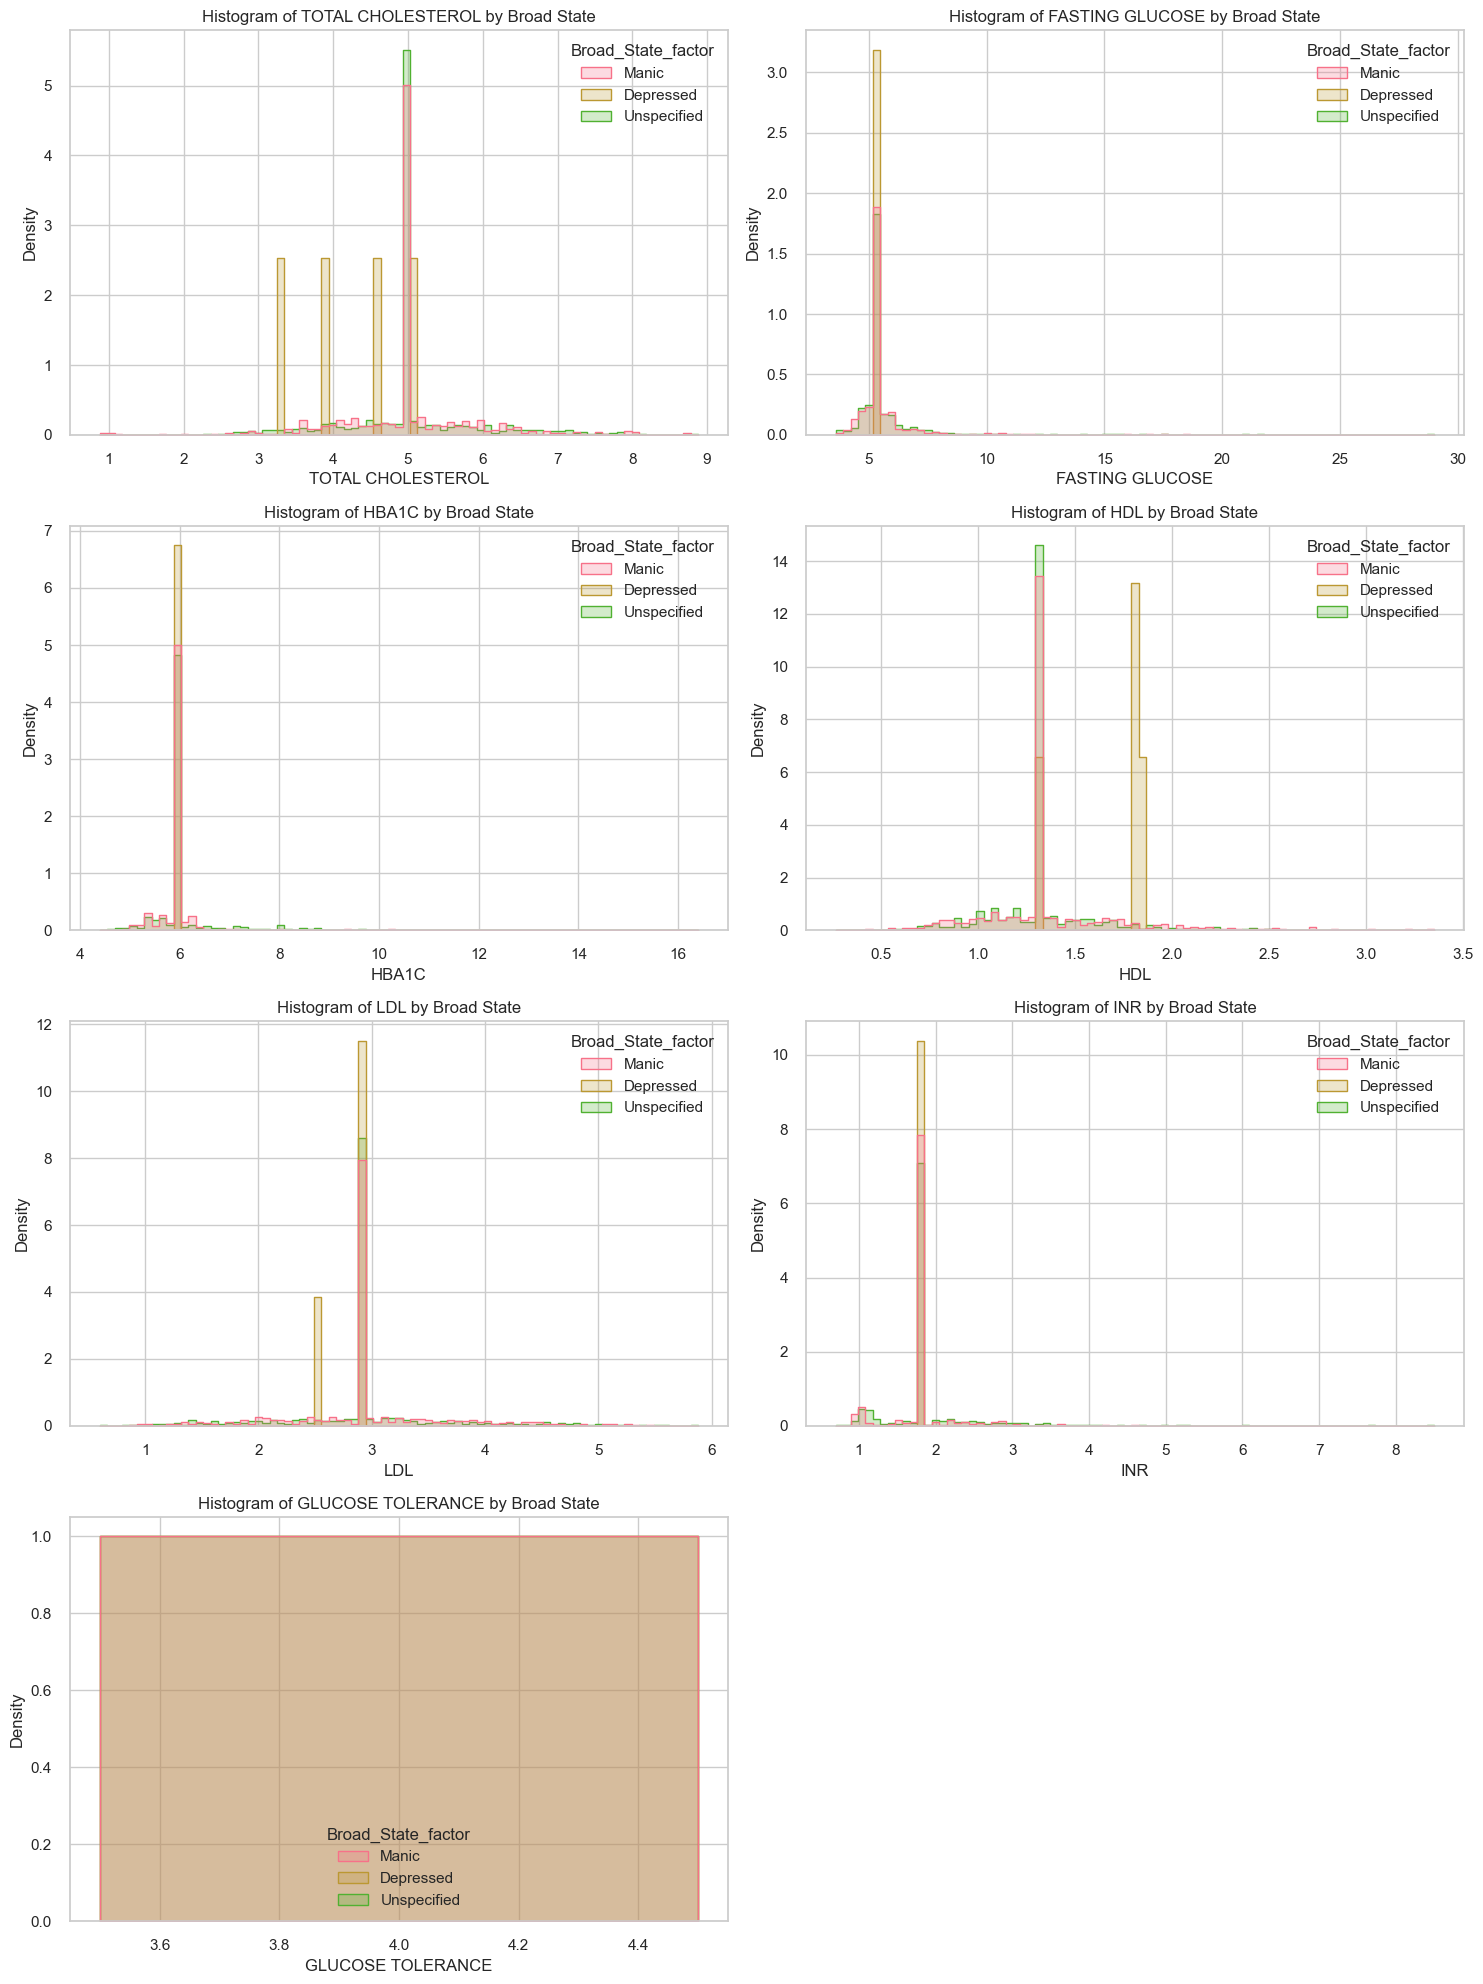

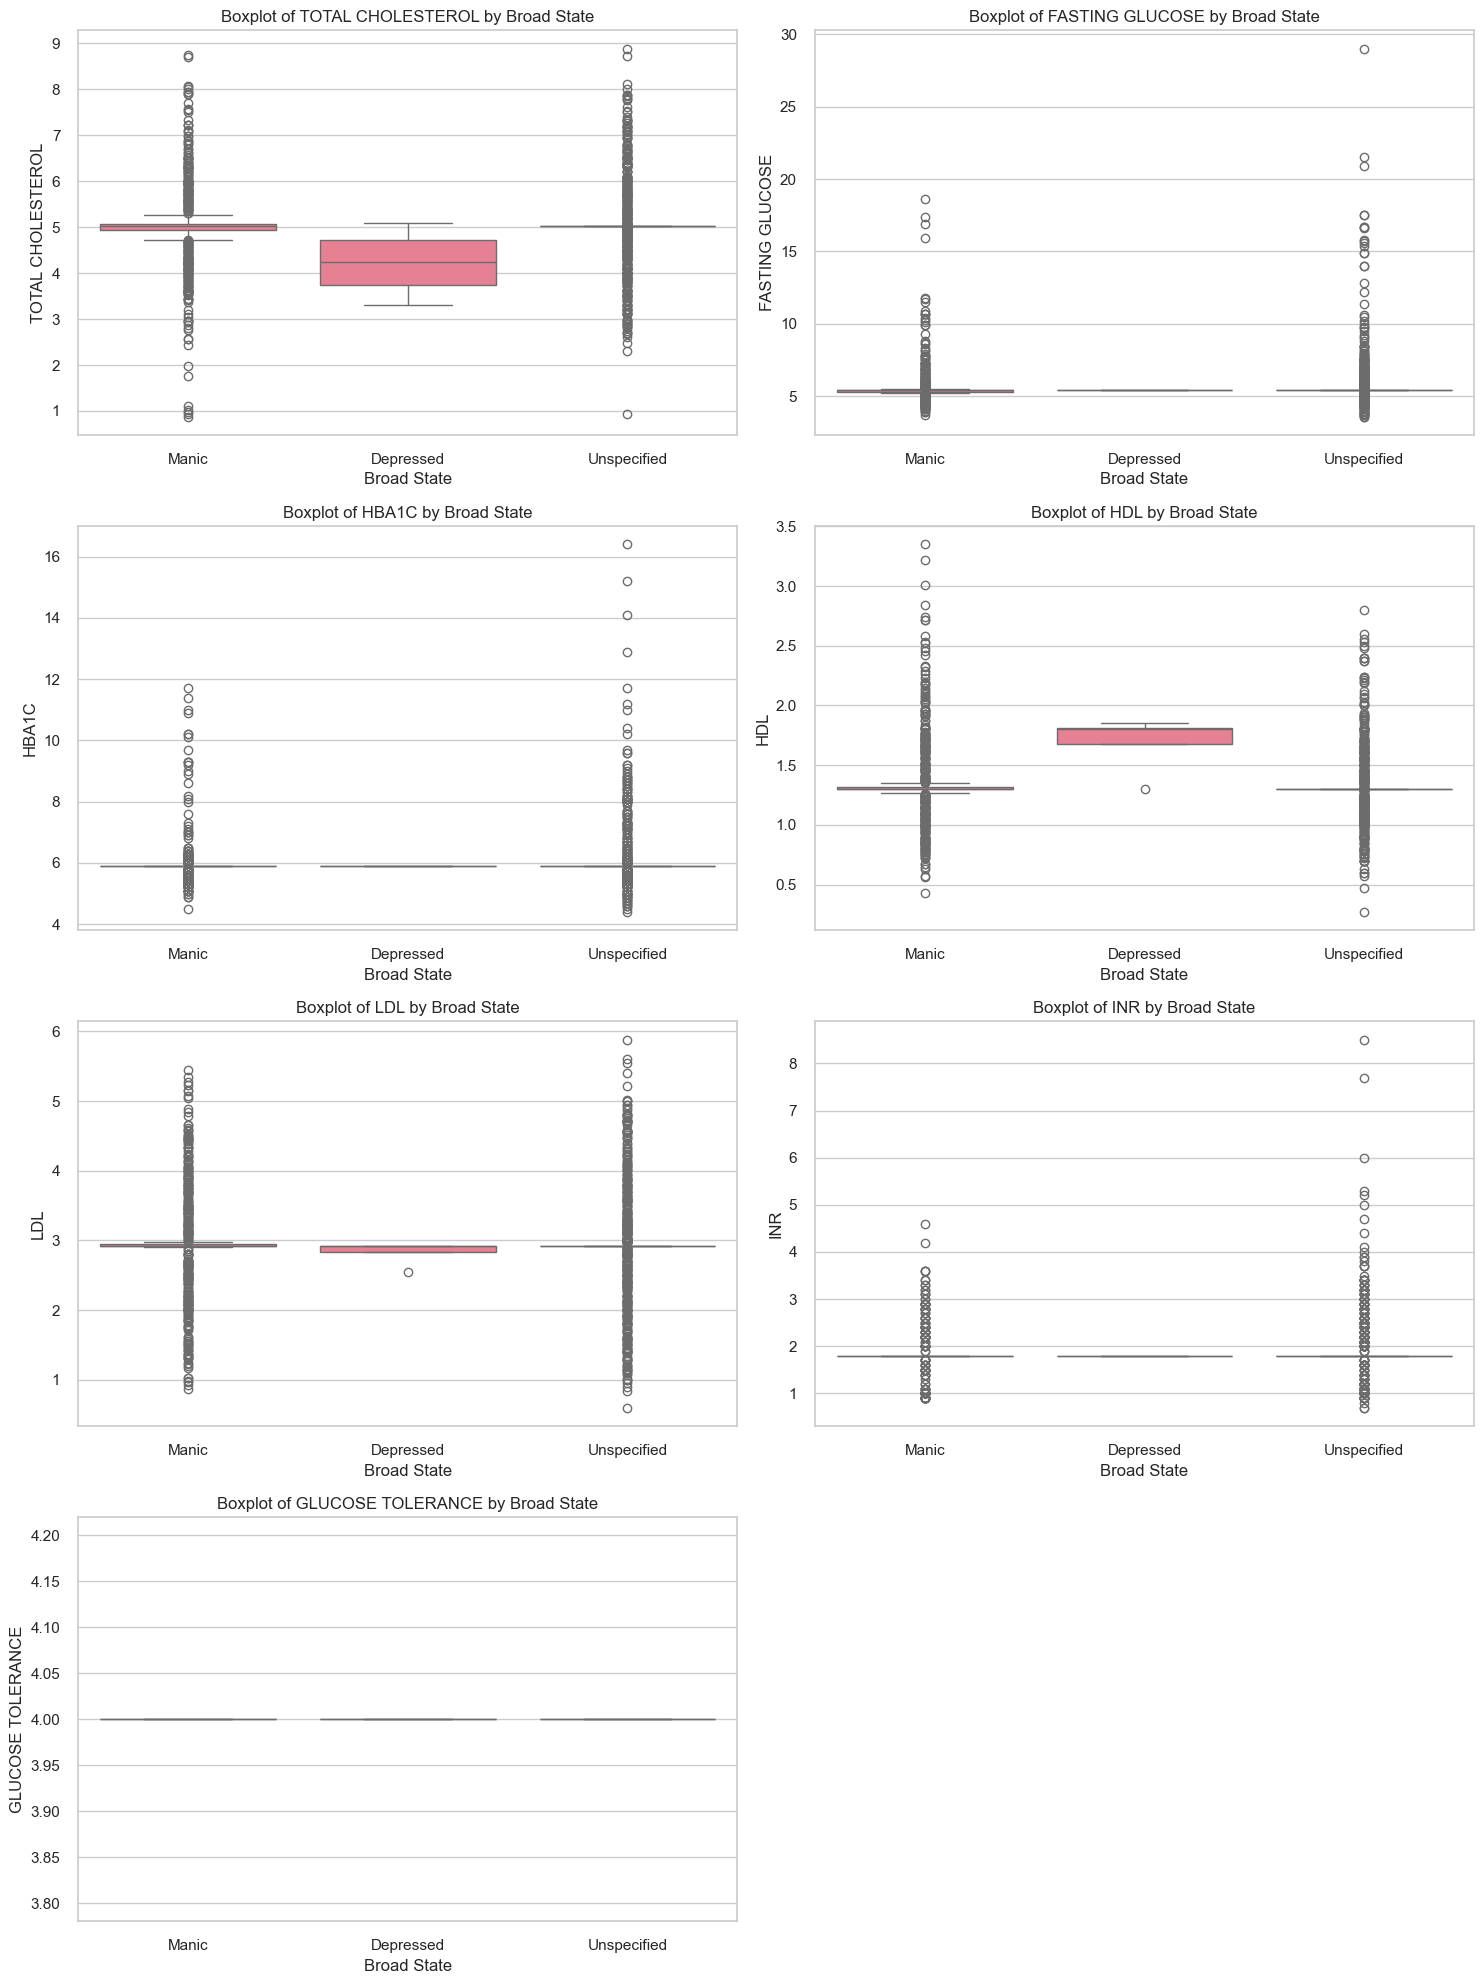

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

lab_vars = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR', 'GLUCOSE TOLERANCE']

# histagram of distribution
plt.figure(figsize=(15, 20))
for i, lab in enumerate(lab_vars, 1):
    plt.subplot(4, 2, i)
    sns.histplot(data=df, x=lab, hue='Broad_State_factor',
                 element='step', stat='density', common_norm=False)
    plt.title(f'Histogram of {lab} by Broad State')
    plt.xlabel(lab)
    plt.ylabel('Density')
plt.tight_layout()
plt.show()

In [ ]:
## Perform the Kruskal-Wallis non-parametric test for each laboratory indicator to determine whether there are significant differences in the distributions of the indicators among different subtypes.

In [156]:
from scipy.stats import kruskal
import numpy as np

for lab in lab_vars:
    df_lab = df_filtered.dropna(subset=[lab, 'State_factor'])
    group_counts = df_lab.groupby('State_factor')[lab].count()
    valid_groups = group_counts[group_counts >= 3].index.tolist()
    
    filtered_groups = []
    for g in valid_groups:
        values = df_lab[df_lab['State_factor'] == g][lab].values
        if len(np.unique(values)) > 1:  # 只有值不全相同时才保留
            filtered_groups.append(g)
    
    if len(filtered_groups) < 2:
        print(f"{lab}: Not enough groups with variation for comparison.")
        continue
    
    groups = [df_lab[df_lab['State_factor'] == g][lab].values for g in filtered_groups]
    stat, p = kruskal(*groups)
    print(f'{lab}: Kruskal-Wallis p-value = {p:.4f}')


TOTAL CHOLESTEROL: Kruskal-Wallis p-value = 0.0017
FASTING GLUCOSE: Kruskal-Wallis p-value = 0.2623
HBA1C: Kruskal-Wallis p-value = 0.0208
HDL: Kruskal-Wallis p-value = 0.0000
LDL: Kruskal-Wallis p-value = 0.0001
INR: Kruskal-Wallis p-value = 0.2539
GLUCOSE TOLERANCE: Not enough groups with variation for comparison.


/var/folders/rz/1kbc3h7x1b94g5f531rphh5m0000gn/T/ipykernel_1526/2316647055.py:6: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



## random forest to see the correlation between lab test and subtypes of bipolar disorder

✅ Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.67      0.35      0.46        17
           2       0.45      0.43      0.44       115
           3       0.00      0.00      0.00         1
           5       0.65      0.69      0.67       188

    accuracy                           0.58       322
   macro avg       0.35      0.30      0.31       322
weighted avg       0.57      0.58      0.57       322

✅ Confusion Matrix:

[[  0   0   1   0   0]
 [  0   6   3   0   8]
 [  0   3  50   0  62]
 [  0   0   0   0   1]
 [  0   0  58   0 130]]


/Users/ervinwu/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/ervinwu/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/ervinwu/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



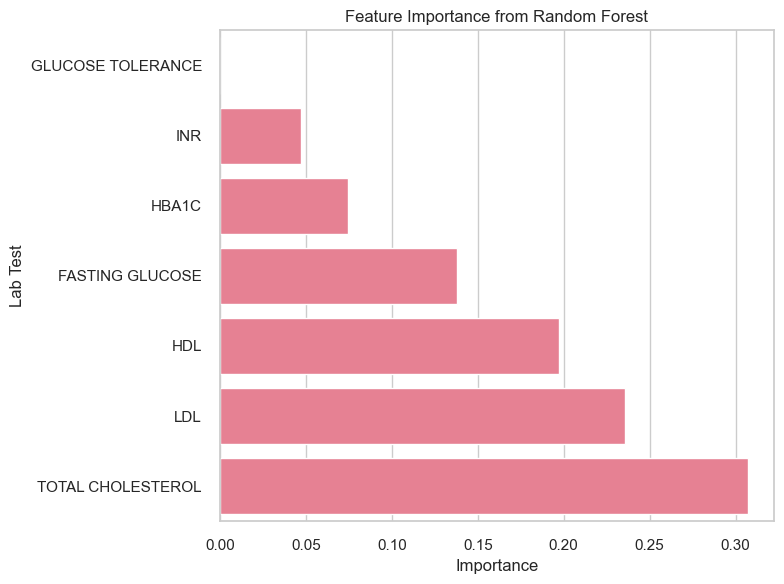

In [148]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

lab_vars = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR', 'GLUCOSE TOLERANCE']

df_clean = df.dropna(subset=lab_vars + ['State_factor'])

df_clean['State_factor_code'] = pd.Categorical(df_clean['State_factor']).codes
y = df_clean['State_factor_code']
X = df_clean[lab_vars]

# keep only classes with at least 2 samples
class_counts = y.value_counts()
valid_classes = class_counts[class_counts >= 2].index.tolist()

df_valid = df_clean[df_clean['State_factor_code'].isin(valid_classes)].copy()

X = df_valid[lab_vars]
y = df_valid['State_factor_code']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# Random Forest classifier
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

# Predict on test set
y_pred = rf.predict(X_test)

print(“Classification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# Feature importance
importances = pd.Series(rf.feature_importances_, index=lab_vars).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance from Random Forest")
plt.xlabel("Importance")
plt.ylabel("Lab Test")
plt.tight_layout()
plt.show()


In [178]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

lab_vars = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR', 'GLUCOSE TOLERANCE']

df_clean = df.dropna(subset=lab_vars + ['State_factor'])

df_clean['State_code'] = pd.Categorical(df_clean['State_factor']).codes
counts = df_clean['State_code'].value_counts()
valid_classes = counts[counts >= 2].index
df_filtered = df_clean[df_clean['State_code'].isin(valid_classes)]

X = df_filtered[lab_vars]
y = df_filtered['State_code']

model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
model.fit(X, y)

coef_df = pd.DataFrame(model.coef_, columns=lab_vars)
coef_df['Class'] = model.classes_

# coef output
coef_df.set_index('Class', inplace=True)
print(coef_df.T.round(3)) 


Class                  0      1      2      3      5
TOTAL CHOLESTEROL  0.152 -0.231  0.293 -0.644  0.430
FASTING GLUCOSE   -0.474  0.098  0.205 -0.050  0.221
HBA1C             -0.157 -0.455  0.270 -0.029  0.371
HDL               -1.061  1.494 -0.715  1.027 -0.744
LDL                1.165  0.119 -0.557 -0.016 -0.711
INR               -0.141 -0.018  0.006 -0.036  0.189
GLUCOSE TOLERANCE -0.409  0.287  0.181 -0.080  0.022


/Users/ervinwu/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.



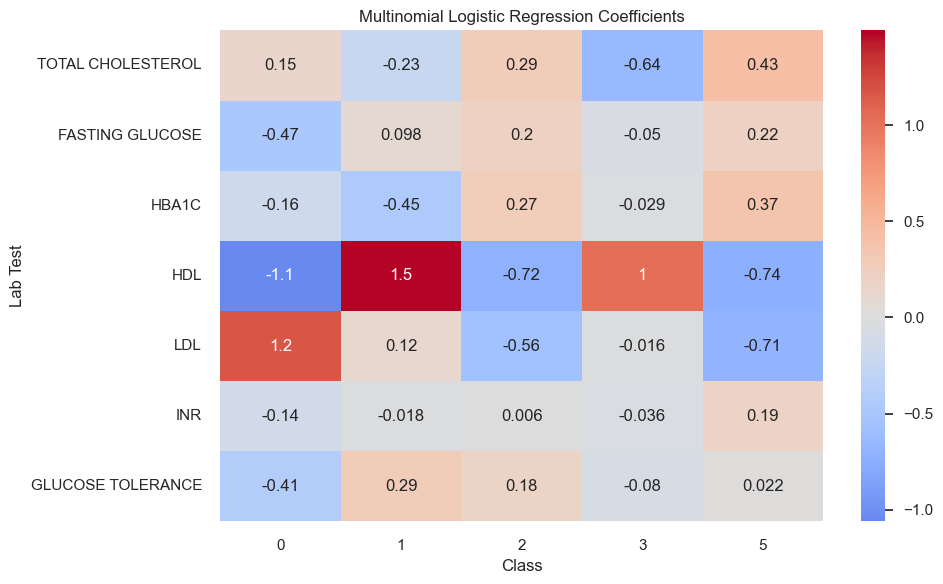

In [179]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(coef_df.T, annot=True, cmap='coolwarm', center=0)
plt.title("Multinomial Logistic Regression Coefficients")
plt.xlabel("Class")
plt.ylabel("Lab Test")
plt.tight_layout()
plt.show()
